# Predicción de demanda eléctrica a 24 horas (24 modelos)

In [ ]:
from pathlib import Path
from datetime import date, timedelta
import hashlib, json, math, os, warnings

import sklearn
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import requests
import holidays
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

Configuración:

In [ ]:
PROJECT_ROOT = Path()
PROCESSED_DIR = PROJECT_ROOT / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts_24_models_24h'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CONSUMPTION = PROCESSED_DIR / 'consumption_all_users.parquet'
INPUT_QUALITY = PROCESSED_DIR / 'quality_report.parquet'
INPUT_METADATA = PROCESSED_DIR / 'metadata_filtered.parquet'
FILTERED_CONSUMPTION = PROCESSED_DIR / 'consumption_users_le10pct_imputed.parquet'
WEATHER_PARQUET = PROCESSED_DIR / 'bilbao_weather_hourly.parquet'
LOCAL_HOLIDAYS_CSV = PROCESSED_DIR / 'bilbao_local_holidays.csv'

MAX_IMPUTED_PCT = 10.0
CONSUMPTION_TIMEZONE = 'UTC'
LOCAL_TIMEZONE = 'Europe/Madrid'
FORECAST_ORIGIN_LOCAL_HOUR = 23
FORECAST_HORIZON = 24

# Splits para train, val y test
TRAIN_END_DATE = date(2021, 6, 1)
VAL_END_DATE = date(2021, 12, 1)
TEST_END_DATE = date(2022, 6, 1)
MIN_EVAL_END_UTC = pd.Timestamp('2022-06-02 00:00:00')

BASE_TRAIN_DAYS_PER_USER = 90
BASE_VAL_DAYS_PER_USER = 45

# Optuna solo sobre horizontes representativos (limitación computacional).
TUNE_TRAIN_DAYS_PER_USER = 180
TUNE_VAL_DAYS_PER_USER = 60
TUNE_HORIZONS = [1, 6, 12, 18, 24]

DIRECT_TRAIN_DAYS_PER_USER = 730
DIRECT_VAL_DAYS_PER_USER = None

RANDOM_SEED = 42
FEATURE_IMPORTANCE_CUMULATIVE_THRESHOLD = 0.97
MIN_SELECTED_FEATURES = 20
MAX_SELECTED_FEATURES = 45
N_OPTUNA_TRIALS = 30

USE_USER_ID_PERSONALIZATION = True

TARGET_LAG_DAYS = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
DAILY_ENERGY_LAGS = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]

PARQUET_COMPRESSION = 'zstd'
OVERWRITE_FILTERED_PARQUET = False

Excluimos usuarios con más del 10% de imputación:

In [ ]:
quality = pd.read_parquet(INPUT_QUALITY)
quality['user_id'] = quality['user_id'].astype(str)
quality['start_date'] = pd.to_datetime(quality['start_date'])
quality['end_date'] = pd.to_datetime(quality['end_date'])

accepted_mask = quality['status'].eq('ok') & quality['imputed_pct'].le(MAX_IMPUTED_PCT)
quality_ok = quality.loc[accepted_mask].copy()
excluded_users = quality.loc[~accepted_mask].copy()

accepted_users = set(quality_ok['user_id'])
evaluation_users = set(quality_ok.loc[quality_ok['end_date'].ge(MIN_EVAL_END_UTC), 'user_id'])

excluded_users.to_csv(ARTIFACTS_DIR / 'excluded_users_gt10pct_imputed.csv', index=False)

print(f'Usuarios iniciales: {len(quality):,}')
print(f'Usuarios aceptados: {len(accepted_users):,}')
print(f'Usuarios excluidos: {len(excluded_users):,}')
print(f'Usuarios con cobertura completa de evaluación: {len(evaluation_users):,}')
display(excluded_users[['user_id','imputed_pct','rows_final']].sort_values('imputed_pct', ascending=False).head(30))

Usuarios iniciales: 1,025
Usuarios aceptados: 1,010
Usuarios excluidos: 15
Usuarios con cobertura completa de evaluación: 923


,user_id,imputed_pct,rows_final
402,66389429a60faabf5a5d8b73a25c0b6d37dcecb4e333f7...,63.917300,41064
953,efe8d8a327e8df89b5906904f6dc2cd7e4a57806a0d477...,60.990676,34320
276,461c48211e7d53887ce74419eba30f3565f333fcfd45d3...,55.270344,43944
978,f471c8f9626d84a950e4774478ddfee413e6a4f0728064...,48.782541,43944
943,ee23472b308a6536b8ec5928be20ea08ed89f75348e1cf...,44.301037,33936
1021,fe73e986873777ffb1973d9ab36485992bebe057ae6bbe...,41.711214,33672
866,dadd1a1228311311a3937be77c2f623040766ef55b80c7...,30.372874,39048
548,8b873da53b135788e0d6b7f2aed92b9537beb65e2963d3...,22.951939,43944
636,a2ada1b5df8539f6479d5f0f6c5bf96ff4318fa4762dca...,18.092593,32400
712,b896709323b7ac9b55308ddafa52851d1f810963a53e6e...,16.798628,30312


In [ ]:
def create_filtered_parquet(input_path, output_path, allowed_users):
    if output_path.exists() and not OVERWRITE_FILTERED_PARQUET:
        print('Ya existe:', output_path)
        return

    tmp = output_path.with_suffix('.tmp.parquet')
    if tmp.exists(): tmp.unlink()
    pf = pq.ParquetFile(input_path)
    writer = None
    n = 0

    try:
        for rg in tqdm(range(pf.num_row_groups), desc='Filtrando usuarios'):
            df = pf.read_row_group(rg).to_pandas()
            df['user_id'] = df['user_id'].astype(str)
            df = df[df['user_id'].isin(allowed_users)]
            if df.empty: continue
            table = pa.Table.from_pandas(df, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(tmp, table.schema, compression=PARQUET_COMPRESSION, write_statistics=True)
            else:
                table = table.cast(writer.schema)
            writer.write_table(table)
            n += len(df)
    finally:
        if writer is not None: writer.close()

    if writer is None:
        raise RuntimeError('No se ha escrito ninguna fila')
    os.replace(tmp, output_path)
    print(f'Filas conservadas: {n:,}')

create_filtered_parquet(INPUT_CONSUMPTION, FILTERED_CONSUMPTION, accepted_users)

Cargamos los Metadatos estáticos de los usuarios:

In [ ]:
metadata = pd.read_parquet(INPUT_METADATA)
if 'user' in metadata.columns and 'user_id' not in metadata.columns:
    metadata = metadata.rename(columns={'user':'user_id'})
metadata['user_id'] = metadata['user_id'].astype(str)
metadata = metadata[metadata['user_id'].isin(accepted_users)].copy()
for c in ['p1','p2']:
    if c in metadata.columns:
        metadata[c] = pd.to_numeric(metadata[c], errors='coerce')
metadata_lookup = metadata.set_index('user_id')
display(metadata.head())

,user_id,start_date,end_date,length_days,length_years,potential_samples,actual_samples,missing_samples_abs,missing_samples_pct,contract_start_date,contract_end_date,contracted_tariff,self_consumption_type,p1,p2,p3,p4,p5,p6,province,municipality,zip_code,cnae
0,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43824,120,0.273075,2021-06-01,NaN,2.0TD,NaN,4.40,4.40,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48012.0,9820.0
1,0062c8d5ca7dfed574aab968f665978a9cb770a0d8f325...,2018-12-05T01:00:00Z,2022-06-05T00:00:00Z,1278.0,3.498973,30672,30665,7,0.022822,2021-06-01,NaN,2.0TD,NaN,2.20,2.20,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48006.0,9820.0
2,00b655f77a0bf8c12323560fa1cd609548ab10782e495b...,2018-09-21T01:00:00Z,2022-06-05T00:00:00Z,1353.0,3.704312,32472,32464,8,0.024637,2021-06-01,NaN,2.0TD,NaN,3.30,3.30,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48006.0,9820.0
3,00db2f868b1075624b10684c1bbade33552a0490b27e01...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43121,823,1.872838,2021-06-01,NaN,2.0TD,NaN,3.45,3.45,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48010.0,9820.0
4,00dcd8d903f75e1f22baa037a7a3ab0fd9bc883614a00c...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43647,297,0.675860,2021-06-01,NaN,2.0TD,NaN,3.30,3.30,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48006.0,9820.0


Descargamos la meteorología histórica de Bilbao desde la API de OpenMeteo:

In [ ]:
BILBAO_LAT = 43.2630
BILBAO_LON = -2.9350
WEATHER_API_URL = 'https://archive-api.open-meteo.com/v1/archive'
WEATHER_VARIABLES = ['temperature_2m','apparent_temperature','relative_humidity_2m',
                     'precipitation','cloud_cover','wind_speed_10m']

def download_weather(start_date, end_date, output_path):
    params = {
        'latitude': BILBAO_LAT,
        'longitude': BILBAO_LON,
        'start_date': str(start_date),
        'end_date': str(end_date),
        'hourly': ','.join(WEATHER_VARIABLES),
        'timezone': 'GMT',
    }
    r = requests.get(WEATHER_API_URL, params=params, timeout=120)
    r.raise_for_status()
    payload = r.json()
    hourly = pd.DataFrame(payload['hourly'])
    hourly['Fecha'] = pd.to_datetime(hourly.pop('time'))
    for c in WEATHER_VARIABLES:
        hourly[c] = pd.to_numeric(hourly[c], errors='coerce').astype('float32')
    hourly.to_parquet(output_path, index=False, compression=PARQUET_COMPRESSION)
    return hourly

weather_start = (quality_ok['start_date'].min() - pd.Timedelta(days=10)).date()
weather_end = (quality_ok['end_date'].max() + pd.Timedelta(days=2)).date()

if WEATHER_PARQUET.exists():
    weather = pd.read_parquet(WEATHER_PARQUET)
else:
    weather = download_weather(weather_start, weather_end, WEATHER_PARQUET)

weather['Fecha'] = pd.to_datetime(weather['Fecha'])
weather_hourly = weather.drop_duplicates('Fecha').sort_values('Fecha').set_index('Fecha')

wd = weather_hourly.reset_index()
wd['local_date'] = pd.DatetimeIndex(wd['Fecha']).tz_localize('UTC').tz_convert(LOCAL_TIMEZONE).date
weather_daily_local = wd.groupby('local_date').agg(
    weather_temp_mean=('temperature_2m','mean'),
    weather_temp_min=('temperature_2m','min'),
    weather_temp_max=('temperature_2m','max'),
    weather_precip_sum=('precipitation','sum'),
).astype('float32')

display(weather_hourly.head())

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m
Fecha,,,,,,
2017-05-18 00:00:00,14.1,13.2,92.0,0.5,100.0,12.8
2017-05-18 01:00:00,13.9,13.0,92.0,1.2,100.0,11.7
2017-05-18 02:00:00,13.9,13.4,91.0,1.2,100.0,8.1
2017-05-18 03:00:00,13.7,12.2,94.0,2.1,100.0,16.1
2017-05-18 04:00:00,13.4,11.7,95.0,0.7,100.0,17.4


Festivos de Bilbao:

In [ ]:
years = range(quality_ok['start_date'].min().year, quality_ok['end_date'].max().year + 1)
pv_holidays = holidays.country_holidays('ES', subdiv='PV', years=years, language='es')
pv_holiday_dates = set(pv_holidays.keys())

bilbao_local_holiday_dates = set()
if LOCAL_HOLIDAYS_CSV.exists():
    lh = pd.read_csv(LOCAL_HOLIDAYS_CSV)
    lh['date'] = pd.to_datetime(lh['date']).dt.date
    bilbao_local_holiday_dates = set(lh['date'])

all_holiday_dates = pv_holiday_dates | bilbao_local_holiday_dates
print('Festivos ES/PV:', len(pv_holiday_dates))
print('Festivos locales Bilbao:', len(bilbao_local_holiday_dates))

Ingeniería de variables multi-horizonte:

In [ ]:
def stable_user_seed(user_id, base_seed=RANDOM_SEED):
    digest = hashlib.sha256(f'{base_seed}-{user_id}'.encode()).hexdigest()[:8]
    return int(digest, 16)

def to_local_time(naive_utc):
    return pd.DatetimeIndex(naive_utc).tz_localize(CONSUMPTION_TIMEZONE).tz_convert(LOCAL_TIMEZONE)

def split_from_date(d):
    if d < TRAIN_END_DATE: return 'train'
    if d < VAL_END_DATE: return 'validation'
    if d < TEST_END_DATE: return 'test'
    return 'unused'

def holiday_arrays(local_dates):
    pv = np.array([d in pv_holiday_dates for d in local_dates], dtype='uint8')
    loc = np.array([d in bilbao_local_holiday_dates for d in local_dates], dtype='uint8')
    hol = np.maximum(pv, loc).astype('uint8')
    before = np.array([(d + timedelta(days=1)) in all_holiday_dates for d in local_dates], dtype='uint8')
    after = np.array([(d - timedelta(days=1)) in all_holiday_dates for d in local_dates], dtype='uint8')
    return pv, loc, hol, before, after

def select_split_positions(pos, max_days, split_name):
    """Train usa recencia; validation/test limitado se reparte por todo el intervalo."""
    pos = np.asarray(pos)

    if max_days is None or len(pos) <= max_days:
        return pos

    if split_name == 'train':
        return pos[-max_days:]

    idx = np.linspace(0, len(pos) - 1, num=max_days, dtype=int)
    return pos[np.unique(idx)]

def safe_cv(std, mean):
    return np.asarray(std) / np.maximum(np.abs(np.asarray(mean)), 1e-6)

In [ ]:
def build_forecast_rows_for_user(user_df, split_day_limits, horizons=None):
    df = user_df.copy()
    df['user_id'] = df['user_id'].astype(str)
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    df = df.sort_values('Fecha').drop_duplicates('Fecha', keep='last').reset_index(drop=True)
    if df.empty:
        return pd.DataFrame()

    user_id = df['user_id'].iloc[0]
    s = pd.to_numeric(df['consumo'], errors='coerce').astype('float64')
    imp = pd.to_numeric(df['imputed'], errors='coerce').fillna(0).astype('uint8')
    ts = pd.DatetimeIndex(df['Fecha'])
    local = to_local_time(df['Fecha'])

    diffs = pd.Series(ts).diff().dropna()
    if not (diffs == pd.Timedelta(hours=1)).all():
        raise ValueError(f'Serie no horaria/continua: {user_id}')

    if horizons is None:
        horizons = list(range(1, FORECAST_HORIZON + 1))
    else:
        horizons = sorted(set(int(h) for h in horizons))
        if not horizons or min(horizons) < 1 or max(horizons) > FORECAST_HORIZON:
            raise ValueError('horizons debe estar contenido entre 1 y FORECAST_HORIZON.')

    r24 = s.rolling(24, min_periods=24)
    r168 = s.rolling(168, min_periods=168)
    r672 = s.rolling(24 * 28, min_periods=24 * 7)

    mean24_s = r24.mean()
    std24_s = r24.std()
    min24_s = r24.min()
    max24_s = r24.max()

    mean168_s = r168.mean()
    std168_s = r168.std()
    min168_s = r168.min()
    max168_s = r168.max()

    mean672_s = r672.mean()
    median672_s = r672.median()
    std672_s = r672.std()
    q90_672_s = s.rolling(24 * 28, min_periods=24 * 7).quantile(0.90)

    scale = mean672_s

    imp24_s = imp.astype(float).rolling(24, min_periods=1).mean()
    imp168_s = imp.astype(float).rolling(168, min_periods=1).mean()

    energy24_s = s.rolling(24, min_periods=24).sum()

    idx = np.arange(len(df))

    min_history = 24 * 28

    mask = (
        (np.asarray(local.hour) == FORECAST_ORIGIN_LOCAL_HOUR)
        & (idx >= min_history)
        & (idx + FORECAST_HORIZON < len(df))
        & scale.notna().to_numpy()
    )

    origins = idx[mask]
    if len(origins) == 0:
        return pd.DataFrame()

    forecast_dates = np.asarray(local[origins + 1].date)
    splits = np.array([split_from_date(d) for d in forecast_dates], dtype=object)

    chosen_chunks = []
    for split_name, max_days in split_day_limits.items():
        pos = np.flatnonzero(splits == split_name)
        if len(pos) == 0:
            continue
        chosen_chunks.append(select_split_positions(pos, max_days, split_name))

    if not chosen_chunks:
        return pd.DataFrame()

    chosen = np.sort(np.concatenate(chosen_chunks))
    origins = origins[chosen]
    forecast_dates = forecast_dates[chosen]
    splits = splits[chosen]

    p1 = p2 = np.nan
    if user_id in metadata_lookup.index:
        if 'p1' in metadata_lookup.columns:
            p1 = metadata_lookup.at[user_id, 'p1']
        if 'p2' in metadata_lookup.columns:
            p2 = metadata_lookup.at[user_id, 'p2']

    recent24_profile = np.column_stack([
        s.iloc[origins - k].to_numpy()
        for k in range(23, -1, -1)
    ])

    recent24_total = recent24_profile.sum(axis=1)
    recent24_peak = recent24_profile.max(axis=1)
    recent24_peak_pos = recent24_profile.argmax(axis=1)

    recent24_night_share = (
        recent24_profile[:, 0:7].sum(axis=1)
        / np.maximum(recent24_total, 1e-6)
    )
    recent24_morning_share = (
        recent24_profile[:, 7:13].sum(axis=1)
        / np.maximum(recent24_total, 1e-6)
    )
    recent24_afternoon_share = (
        recent24_profile[:, 13:19].sum(axis=1)
        / np.maximum(recent24_total, 1e-6)
    )
    recent24_evening_share = (
        recent24_profile[:, 19:24].sum(axis=1)
        / np.maximum(recent24_total, 1e-6)
    )

    daily_energy = {}
    for d in DAILY_ENERGY_LAGS:
        pos = origins - 24 * (d - 1)
        daily_energy[d] = energy24_s.iloc[pos].to_numpy()

    daily7 = np.column_stack([daily_energy[d] for d in range(1, 8)])
    daily_mean_7 = np.nanmean(daily7, axis=1)
    daily_std_7 = np.nanstd(daily7, axis=1)

    daily_same_weekday_4w = np.column_stack([
        daily_energy[d] for d in [7, 14, 21, 28]
    ])
    daily_same_weekday_mean_4w = np.nanmean(daily_same_weekday_4w, axis=1)

    blocks = []

    for h in horizons:
        tp = origins + h
        target_ts = ts[tp]
        target_local = local[tp]
        dates = np.asarray(target_local.date)

        pv, loc_h, hol, before, after = holiday_arrays(dates)

        hour = np.asarray(target_local.hour)
        dow = np.asarray(target_local.dayofweek)
        month = np.asarray(target_local.month)
        doy = np.asarray(target_local.dayofyear)

        w = weather_hourly.reindex(pd.DatetimeIndex(target_ts))
        w_prev24 = weather_hourly.reindex(
            pd.DatetimeIndex(target_ts) - pd.Timedelta(hours=24)
        )
        daily = weather_daily_local.reindex(dates)

        sc = scale.iloc[origins].to_numpy()
        y = s.iloc[tp].to_numpy()

        lag_values = {}
        lag_imputed = {}

        for d in TARGET_LAG_DAYS:
            pos = tp - 24 * d
            lag_values[d] = s.iloc[pos].to_numpy()
            lag_imputed[d] = imp.iloc[pos].to_numpy().astype('uint8')

        last7 = np.column_stack([lag_values[d] for d in range(1, 8)])
        same_hour_mean_7d = np.nanmean(last7, axis=1)
        same_hour_median_7d = np.nanmedian(last7, axis=1)
        same_hour_std_7d = np.nanstd(last7, axis=1)

        weekly4 = np.column_stack([
            lag_values[d] for d in [7, 14, 21, 28]
        ])
        same_hour_mean_4w = np.nanmean(weekly4, axis=1)
        same_hour_median_4w = np.nanmedian(weekly4, axis=1)

        robust_baseline = np.nanmedian(
            np.column_stack([
                lag_values[1], lag_values[2], lag_values[3],
                lag_values[4], lag_values[5], lag_values[6],
                lag_values[7], lag_values[14],
                lag_values[21], lag_values[28],
            ]),
            axis=1,
        )

        weighted_baseline = (
            0.45 * lag_values[1]
            + 0.25 * lag_values[7]
            + 0.30 * same_hour_mean_4w
        )

        temperature = w['temperature_2m'].to_numpy(dtype='float32')
        temperature_prev24 = w_prev24['temperature_2m'].to_numpy(dtype='float32')

        b = pd.DataFrame({
            'user_id': user_id,
            'origin_time_utc': ts[origins],
            'target_time_utc': target_ts,
            'forecast_date': forecast_dates,
            'split': splits,

            # Targets / baselines
            'target': y.astype('float32'),
            'target_imputed': imp.iloc[tp].to_numpy().astype('uint8'),
            'scale_28d': sc.astype('float32'),
            'target_rel': (y / np.maximum(sc, 1e-6)).astype('float32'),
            'robust_baseline': robust_baseline.astype('float32'),
            'weighted_baseline': weighted_baseline.astype('float32'),
            'target_residual': (y - robust_baseline).astype('float32'),

            'horizon': np.int8(h),

            # Calendario
            'target_hour': hour.astype('int8'),
            'target_dayofweek': dow.astype('int8'),
            'target_month': month.astype('int8'),
            'target_dayofyear': doy.astype('int16'),
            'target_is_weekend': (dow >= 5).astype('uint8'),
            'target_hour_sin': np.sin(2 * np.pi * hour / 24).astype('float32'),
            'target_hour_cos': np.cos(2 * np.pi * hour / 24).astype('float32'),
            'target_dow_sin': np.sin(2 * np.pi * dow / 7).astype('float32'),
            'target_dow_cos': np.cos(2 * np.pi * dow / 7).astype('float32'),
            'target_doy_sin': np.sin(2 * np.pi * doy / 365.25).astype('float32'),
            'target_doy_cos': np.cos(2 * np.pi * doy / 365.25).astype('float32'),

            # Festivos
            'is_public_holiday_pv': pv,
            'is_bilbao_local_holiday': loc_h,
            'is_holiday': hol,
            'is_day_before_holiday': before,
            'is_day_after_holiday': after,

            # Perfiles de la misma hora
            'same_hour_mean_7d': same_hour_mean_7d.astype('float32'),
            'same_hour_median_7d': same_hour_median_7d.astype('float32'),
            'same_hour_std_7d': same_hour_std_7d.astype('float32'),
            'same_hour_mean_4w': same_hour_mean_4w.astype('float32'),
            'same_hour_median_4w': same_hour_median_4w.astype('float32'),
            'same_hour_change_d1_vs_7d': (
                lag_values[1] - same_hour_mean_7d
            ).astype('float32'),
            'same_hour_change_d1_vs_w1': (
                lag_values[1] - lag_values[7]
            ).astype('float32'),

            # Estado reciente raw
            'last_consumption': s.iloc[origins].to_numpy().astype('float32'),
            'rolling_mean_24': mean24_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_std_24': std24_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_min_24': min24_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_max_24': max24_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_cv_24': safe_cv(
                std24_s.iloc[origins].to_numpy(),
                mean24_s.iloc[origins].to_numpy(),
            ).astype('float32'),

            'rolling_mean_168': mean168_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_std_168': std168_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_min_168': min168_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_max_168': max168_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_cv_168': safe_cv(
                std168_s.iloc[origins].to_numpy(),
                mean168_s.iloc[origins].to_numpy(),
            ).astype('float32'),

            'rolling_mean_28d': mean672_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_median_28d': median672_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_std_28d': std672_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_q90_28d': q90_672_s.iloc[origins].to_numpy().astype('float32'),
            'rolling_cv_28d': safe_cv(
                std672_s.iloc[origins].to_numpy(),
                mean672_s.iloc[origins].to_numpy(),
            ).astype('float32'),

            'last_consumption_rel': (
                s.iloc[origins].to_numpy() / np.maximum(sc, 1e-6)
            ).astype('float32'),
            'rolling_mean_24_rel': (
                mean24_s.iloc[origins].to_numpy() / np.maximum(sc, 1e-6)
            ).astype('float32'),
            'rolling_mean_168_rel': (
                mean168_s.iloc[origins].to_numpy() / np.maximum(sc, 1e-6)
            ).astype('float32'),

            'past_imputed_frac_24': imp24_s.iloc[origins].to_numpy().astype('float32'),
            'past_imputed_frac_168': imp168_s.iloc[origins].to_numpy().astype('float32'),

            # Energía diaria / actividad
            'daily_mean_7': daily_mean_7.astype('float32'),
            'daily_std_7': daily_std_7.astype('float32'),
            'daily_cv_7': safe_cv(daily_std_7, daily_mean_7).astype('float32'),
            'daily_same_weekday_mean_4w': daily_same_weekday_mean_4w.astype('float32'),
            'daily_change_d1_vs_7d': (
                daily_energy[1] - daily_mean_7
            ).astype('float32'),

            # Perfil de las últimas 24 h
            'recent24_total': recent24_total.astype('float32'),
            'recent24_peak': recent24_peak.astype('float32'),
            'recent24_peak_pos': recent24_peak_pos.astype('int8'),
            'recent24_night_share': recent24_night_share.astype('float32'),
            'recent24_morning_share': recent24_morning_share.astype('float32'),
            'recent24_afternoon_share': recent24_afternoon_share.astype('float32'),
            'recent24_evening_share': recent24_evening_share.astype('float32'),

            # Metadata
            'contracted_power_p1': np.float32(p1) if pd.notna(p1) else np.nan,
            'contracted_power_p2': np.float32(p2) if pd.notna(p2) else np.nan,

            # Meteorología objetivo
            'temperature_2m': temperature,
            'apparent_temperature': w['apparent_temperature'].to_numpy(dtype='float32'),
            'relative_humidity_2m': w['relative_humidity_2m'].to_numpy(dtype='float32'),
            'precipitation': w['precipitation'].to_numpy(dtype='float32'),
            'cloud_cover': w['cloud_cover'].to_numpy(dtype='float32'),
            'wind_speed_10m': w['wind_speed_10m'].to_numpy(dtype='float32'),
            'weather_temp_mean': daily['weather_temp_mean'].to_numpy(dtype='float32'),
            'weather_temp_min': daily['weather_temp_min'].to_numpy(dtype='float32'),
            'weather_temp_max': daily['weather_temp_max'].to_numpy(dtype='float32'),
            'weather_precip_sum': daily['weather_precip_sum'].to_numpy(dtype='float32'),

            # Transformaciones meteorológicas no lineales
            'heating_degree_15': np.maximum(15.0 - temperature, 0.0).astype('float32'),
            'cooling_degree_22': np.maximum(temperature - 22.0, 0.0).astype('float32'),
            'temperature_change_24h': (
                temperature - temperature_prev24
            ).astype('float32'),

            'lag_24_target': lag_values[1].astype('float32'),
            'lag_168_target': lag_values[7].astype('float32'),
            'lag_336_target': lag_values[14].astype('float32'),
            'lag_24_target_rel': (
                lag_values[1] / np.maximum(sc, 1e-6)
            ).astype('float32'),
            'lag_168_target_rel': (
                lag_values[7] / np.maximum(sc, 1e-6)
            ).astype('float32'),
            'lag_336_target_rel': (
                lag_values[14] / np.maximum(sc, 1e-6)
            ).astype('float32'),
            'lag_24_target_imputed': lag_imputed[1],
            'lag_168_target_imputed': lag_imputed[7],
            'lag_336_target_imputed': lag_imputed[14],
        })

        # Lags de la misma hora y sus banderas de imputación
        for d in TARGET_LAG_DAYS:
            b[f'lag_d{d}'] = lag_values[d].astype('float32')
            b[f'lag_d{d}_imputed'] = lag_imputed[d]

        # Energía de días/ventanas anteriores
        for d in DAILY_ENERGY_LAGS:
            b[f'daily_energy_d{d}'] = daily_energy[d].astype('float32')

        # Perfil horario completo de las últimas 24 h
        for j in range(24):
            b[f'recent24_pos{j:02d}'] = recent24_profile[:, j].astype('float32')

        blocks.append(b)

    out = pd.concat(blocks, ignore_index=True)

    return out[
        out['target'].notna()
        & out['scale_28d'].notna()
        & out['robust_baseline'].notna()
    ].copy()

Features base y comprobación de un usuario:

In [ ]:
FEATURE_COLUMNS_BASE = [
    # Horizonte y calendario
    'horizon','target_hour','target_dayofweek','target_month','target_dayofyear','target_is_weekend',
    'target_hour_sin','target_hour_cos','target_dow_sin','target_dow_cos','target_doy_sin','target_doy_cos',

    # Festivos
    'is_public_holiday_pv','is_bilbao_local_holiday','is_holiday','is_day_before_holiday','is_day_after_holiday',

    # Baseline y perfiles de la misma hora
    'robust_baseline','weighted_baseline',
    'same_hour_mean_7d','same_hour_median_7d','same_hour_std_7d',
    'same_hour_mean_4w','same_hour_median_4w',
    'same_hour_change_d1_vs_7d','same_hour_change_d1_vs_w1',

    # Estado reciente
    'last_consumption',
    'rolling_mean_24','rolling_std_24','rolling_min_24','rolling_max_24','rolling_cv_24',
    'rolling_mean_168','rolling_std_168','rolling_min_168','rolling_max_168','rolling_cv_168',
    'rolling_mean_28d','rolling_median_28d','rolling_std_28d','rolling_q90_28d','rolling_cv_28d',
    'past_imputed_frac_24','past_imputed_frac_168',

    # Energía diaria y forma del día reciente
    'daily_mean_7','daily_std_7','daily_cv_7','daily_same_weekday_mean_4w','daily_change_d1_vs_7d',
    'recent24_total','recent24_peak','recent24_peak_pos',
    'recent24_night_share','recent24_morning_share','recent24_afternoon_share','recent24_evening_share',

    # Metadata
    'contracted_power_p1','contracted_power_p2',

    # Meteorología
    'temperature_2m','apparent_temperature','relative_humidity_2m','precipitation','cloud_cover','wind_speed_10m',
    'weather_temp_mean','weather_temp_min','weather_temp_max','weather_precip_sum',
    'heating_degree_15','cooling_degree_22','temperature_change_24h',
]

FEATURE_COLUMNS_BASE += [f'lag_d{d}' for d in TARGET_LAG_DAYS]
FEATURE_COLUMNS_BASE += [f'lag_d{d}_imputed' for d in TARGET_LAG_DAYS]
FEATURE_COLUMNS_BASE += [f'daily_energy_d{d}' for d in DAILY_ENERGY_LAGS]
FEATURE_COLUMNS_BASE += [f'recent24_pos{j:02d}' for j in range(24)]

print('Nº features base V2:', len(FEATURE_COLUMNS_BASE))

pf = pq.ParquetFile(FILTERED_CONSUMPTION)
example = pf.read_row_group(0).to_pandas()
example_rows = build_forecast_rows_for_user(example, {'train':2,'validation':1,'test':1})
display(example_rows.head(30))

Nº features base V2: 125


,user_id,origin_time_utc,target_time_utc,forecast_date,split,target,target_imputed,scale_28d,target_rel,robust_baseline,weighted_baseline,target_residual,horizon,target_hour,target_dayofweek,target_month,target_dayofyear,target_is_weekend,target_hour_sin,target_hour_cos,target_dow_sin,target_dow_cos,target_doy_sin,target_doy_cos,is_public_holiday_pv,is_bilbao_local_holiday,is_holiday,is_day_before_holiday,is_day_after_holiday,same_hour_mean_7d,same_hour_median_7d,same_hour_std_7d,same_hour_mean_4w,same_hour_median_4w,same_hour_change_d1_vs_7d,same_hour_change_d1_vs_w1,last_consumption,rolling_mean_24,rolling_std_24,rolling_min_24,rolling_max_24,rolling_cv_24,rolling_mean_168,rolling_std_168,rolling_min_168,rolling_max_168,rolling_cv_168,rolling_mean_28d,rolling_median_28d,rolling_std_28d,rolling_q90_28d,rolling_cv_28d,last_consumption_rel,rolling_mean_24_rel,rolling_mean_168_rel,past_imputed_frac_24,past_imputed_frac_168,daily_mean_7,daily_std_7,daily_cv_7,...,lag_24_target_rel,lag_168_target_rel,lag_336_target_rel,lag_24_target_imputed,lag_168_target_imputed,lag_336_target_imputed,lag_d1,lag_d1_imputed,lag_d2,lag_d2_imputed,lag_d3,lag_d3_imputed,lag_d4,lag_d4_imputed,lag_d5,lag_d5_imputed,lag_d6,lag_d6_imputed,lag_d7,lag_d7_imputed,lag_d14,lag_d14_imputed,lag_d21,lag_d21_imputed,lag_d28,lag_d28_imputed,daily_energy_d1,daily_energy_d2,daily_energy_d3,daily_energy_d4,daily_energy_d5,daily_energy_d6,daily_energy_d7,daily_energy_d14,daily_energy_d21,daily_energy_d28,recent24_pos00,recent24_pos01,recent24_pos02,recent24_pos03,recent24_pos04,recent24_pos05,recent24_pos06,recent24_pos07,recent24_pos08,recent24_pos09,recent24_pos10,recent24_pos11,recent24_pos12,recent24_pos13,recent24_pos14,recent24_pos15,recent24_pos16,recent24_pos17,recent24_pos18,recent24_pos19,recent24_pos20,recent24_pos21,recent24_pos22,recent24_pos23
0,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2021-05-29 21:00:00,2021-05-29 22:00:00,2021-05-30,train,0.072,0,0.202683,0.355234,0.3055,0.430875,-0.2335,1,0,6,5,150,1,0.000000,1.000000e+00,-0.781832,0.623490,0.532227,-0.846602,0,0,0,0,0,0.341857,0.326,0.137522,0.30125,0.2850,0.273143,0.360,0.063,0.216000,0.211146,0.046,0.720,0.977528,0.195304,0.192550,0.041,0.997,0.985901,0.202683,0.1495,0.196696,0.4288,0.970461,0.310830,1.065703,0.963591,0.0,0.0,4.687286,0.820096,0.174962,...,3.034294,1.258122,1.406136,0,0,0,0.615,0,0.198,0,0.326,0,0.336,0,0.211,0,0.452,0,0.255,0,0.285,0,0.285,0,0.380,0,5.184,4.684,3.847,4.070,6.271,4.958,3.797,9.252,6.295,5.506,0.615,0.219,0.186,0.159,0.152,0.104,0.046,0.056,0.047,0.211,0.204,0.308,0.243,0.699,0.556,0.720,0.160,0.082,0.076,0.065,0.076,0.063,0.074,0.063
1,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2021-05-30 21:00:00,2021-05-30 22:00:00,2021-05-31,train,0.060,0,0.196844,0.304810,0.3310,0.276800,-0.2710,1,0,0,5,151,0,0.000000,1.000000e+00,0.000000,1.000000,0.517586,-0.855631,0,0,0,0,0,0.315714,0.326,0.165995,0.43800,0.4820,-0.243714,-0.380,0.069,0.065917,0.005132,0.057,0.074,0.077861,0.182119,0.192637,0.043,0.997,1.057750,0.196844,0.1365,0.195054,0.4080,0.990910,0.350532,0.334868,0.925196,0.0,0.0,4.370857,1.355265,0.310068,...,0.365772,2.296237,2.601048,0,0,0,0.072,0,0.615,0,0.198,0,0.326,0,0.336,0,0.211,0,0.452,0,0.512,0,0.535,0,0.253,0,1.582,5.184,4.684,3.847,4.070,6.271,4.958,4.601,4.273,3.605,0.072,0.058,0.071,0.062,0.072,0.065,0.068,0.065,0.057,0.074,0.063,0.073,0.063,0.059,0.067,0.063,0.073,0.063,0.063,0.063,0.063,0.073,0.063,0.069
2,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2021-05-31 21:00:00,2021-05-31 22:00:00,2021-06-01,validation,1.121,0,0.196012,5.719041,0.2685,0.225850,0.8525,1,0,1,6,152,0,0.000000,1.000000e+00,0.781832,0.623490,0.502791,-0.864408,0,0,0,0,0,0.259714,0.211,0.176370,0.48700,0.4845,-0.199714,-0.151,0.366,0.126917,0.103585,0.044,0.428,0.816167,0.170738,0.186441,0.043,0.997,1.091970,0.196012,0.1380,0.193761,0.4080,0.988517,1.867234,0.647495,0.871060,0.0,0.0,4.097714,1.401299,0.341971,...,0.306104,1.076465,4.009961,0,0,0,0.060,0,0.072,0

Crear muestras equilibradas de train/val :

In [ ]:
def build_sample_dataset(split_day_limits, allowed_user_ids=None):
    pf = pq.ParquetFile(FILTERED_CONSUMPTION)
    chunks=[]
    for rg in tqdm(range(pf.num_row_groups), desc=f'Muestra {split_day_limits}'):
        g = pf.read_row_group(rg).to_pandas()
        for uid, udf in g.groupby('user_id', sort=False):
            uid = str(uid)
            if allowed_user_ids is not None and uid not in allowed_user_ids: continue
            rows = build_forecast_rows_for_user(udf, split_day_limits)
            if not rows.empty: chunks.append(rows)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

base_sample = build_sample_dataset({'train':BASE_TRAIN_DAYS_PER_USER,'validation':BASE_VAL_DAYS_PER_USER})
base_train = base_sample[(base_sample['split']=='train') & (base_sample['target_imputed']==0)].copy()
base_val = base_sample[(base_sample['split']=='validation') & (base_sample['target_imputed']==0) & base_sample['user_id'].isin(evaluation_users)].copy()
print(f'Train: {len(base_train):,} | Validation: {len(base_val):,}')

Muestra {'train': 90, 'validation': 45}: 100%|██████████| 1010/1010 [25:32<00:00,  1.52s/it]


Train: 2,180,600 | Validation: 996,840


Métricas y baselines:

In [ ]:
def regression_metrics(y_true, y_pred):
    y_true=np.asarray(y_true,dtype=float); y_pred=np.asarray(y_pred,dtype=float)
    valid=np.isfinite(y_true)&np.isfinite(y_pred); y_true=y_true[valid]; y_pred=y_pred[valid]
    err=y_pred-y_true
    return {
        'n':len(y_true),
        'MAE':np.mean(np.abs(err)),
        'RMSE':np.sqrt(np.mean(err**2)),
        'WAPE_pct':100*np.sum(np.abs(err))/max(np.sum(np.abs(y_true)),1e-8),
        'sMAPE_pct':100*np.mean(2*np.abs(err)/np.maximum(np.abs(y_true)+np.abs(y_pred),1e-8)),
        'R2':float(r2_score(y_true,y_pred)),
    }

def predictions_to_kwh(pred_rel, scale):
    return np.maximum(np.asarray(pred_rel)*np.asarray(scale), 0.0)

def eval_predictions(df, pred, name):
    rows=[{'model':name,'scope':'overall','horizon':0,**regression_metrics(df['target'],pred)}]
    pser=pd.Series(np.asarray(pred), index=df.index)
    for h, idx in df.groupby('horizon').groups.items():
        idx=list(idx)
        rows.append({'model':name,'scope':'horizon','horizon':int(h),**regression_metrics(df.loc[idx,'target'],pser.loc[idx])})
    return pd.DataFrame(rows)

baseline_results=[]
for name,pred in {
    'Naive_D-1':base_val['lag_24_target'].to_numpy(),
    'Naive_W-1':base_val['lag_168_target'].to_numpy(),
    'Naive_mean_D1_W1':(base_val['lag_24_target'].to_numpy()+base_val['lag_168_target'].to_numpy())/2,
    'SameHour_mean_7d':base_val['same_hour_mean_7d'].to_numpy(),
    'SameHour_median_7d':base_val['same_hour_median_7d'].to_numpy(),
    'Robust_multiweek_median':base_val['robust_baseline'].to_numpy(),
}.items():
    baseline_results.append(eval_predictions(base_val,pred,name))

baseline_results=pd.concat(baseline_results,ignore_index=True)
display(baseline_results[baseline_results.scope=='overall'].sort_values('WAPE_pct'))

,model,scope,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
125,Robust_multiweek_median,overall,0,996840,0.089564,0.210407,50.695257,43.942643,0.378733
100,SameHour_median_7d,overall,0,996840,0.093907,0.218615,53.153929,45.243534,0.329317
75,SameHour_mean_7d,overall,0,996840,0.103752,0.210141,58.726210,50.884164,0.380304
50,Naive_mean_D1_W1,overall,0,996840,0.107239,0.225781,60.699768,49.613036,0.284631
0,Naive_D-1,overall,0,996840,0.117480,0.260882,66.496780,50.640558,0.044907
25,Naive_W-1,overall,0,996840,0.121572,0.268763,68.812773,54.241284,-0.013672


Modelos base: LightGBM, XGBoost y CatBoost:

In [ ]:
MODEL_NAMES=['LightGBM','XGBoost','CatBoost']

import xgboost as xgb
from packaging.version import Version

def default_params(name):
    if name=='LightGBM':
        return dict(
            objective='regression_l1',
            n_estimators=700,
            learning_rate=.04,
            num_leaves=96,
            max_depth=-1,
            min_child_samples=80,
            subsample=.9,
            colsample_bytree=.9,
            reg_lambda=1.,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=-1,
        )
    if name=='XGBoost':
        objective = 'reg:absoluteerror' if Version(xgb.__version__) >= Version('1.7.0') else 'reg:squarederror'
        return dict(
            objective=objective,
            n_estimators=700,
            learning_rate=.04,
            max_depth=8,
            min_child_weight=5,
            subsample=.9,
            colsample_bytree=.9,
            reg_lambda=1.,
            tree_method='hist',
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
    if name=='CatBoost':
        return dict(
            loss_function='MAE',
            iterations=700,
            learning_rate=.04,
            depth=8,
            l2_leaf_reg=3.,
            random_seed=RANDOM_SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
    raise ValueError(name)

def build_model(name, params=None):
    p=default_params(name)
    if params:
        p.update(params)
    if name=='LightGBM':
        return LGBMRegressor(**p)
    if name=='XGBoost':
        return XGBRegressor(**p)
    if name=='CatBoost':
        return CatBoostRegressor(**p)
    raise ValueError(name)

def prepare_xy(df, features, target_mode=None):
    X=df[features].replace([np.inf,-np.inf],np.nan).astype('float32')

    if target_mode is None:
        target_mode = BEST_TARGET_MODE

    if target_mode=='raw':
        y=df['target'].astype('float32')
    elif target_mode=='residual':
        y=df['target_residual'].astype('float32')
    else:
        raise ValueError(target_mode)

    return X,y

def restore_prediction(df, internal_pred, target_mode=None):
    if target_mode is None:
        target_mode = BEST_TARGET_MODE

    internal_pred=np.asarray(internal_pred,dtype=float)

    if target_mode=='raw':
        pred=internal_pred
    elif target_mode=='residual':
        pred=df['robust_baseline'].to_numpy(dtype=float)+internal_pred
    else:
        raise ValueError(target_mode)

    return np.maximum(pred,0.0)


target_mode_rows=[]
target_mode_models={}

for mode in ['raw','residual']:
    Xtr_mode,ytr_mode=prepare_xy(base_train,FEATURE_COLUMNS_BASE,target_mode=mode)
    Xva_mode,yva_mode=prepare_xy(base_val,FEATURE_COLUMNS_BASE,target_mode=mode)

    m=build_model('LightGBM')
    m.fit(Xtr_mode,ytr_mode)

    pred=restore_prediction(
        base_val,
        m.predict(Xva_mode),
        target_mode=mode,
    )

    row={'target_mode':mode}
    row.update(regression_metrics(base_val['target'],pred))
    target_mode_rows.append(row)
    target_mode_models[mode]=m

target_mode_results=pd.DataFrame(target_mode_rows).sort_values('WAPE_pct').reset_index(drop=True)
display(target_mode_results)

BEST_TARGET_MODE=target_mode_results.iloc[0]['target_mode']
print('Target elegido para el resto del pipeline:',BEST_TARGET_MODE)

Xtr,ytr=prepare_xy(base_train,FEATURE_COLUMNS_BASE)
Xva,yva=prepare_xy(base_val,FEATURE_COLUMNS_BASE)

base_models={}
base_results=[]

for name in MODEL_NAMES:
    print('Entrenando',name)
    m=build_model(name)
    m.fit(Xtr,ytr)
    base_models[name]=m

    joblib.dump(m,ARTIFACTS_DIR/f'{name}_base.pkl')
    joblib.dump(FEATURE_COLUMNS_BASE,ARTIFACTS_DIR/f'{name}_base_features.pkl')

    pred=restore_prediction(base_val,m.predict(Xva))
    base_results.append(eval_predictions(base_val,pred,f'{name}_base'))

base_results=pd.concat(base_results,ignore_index=True)
display(base_results[base_results.scope=='overall'].sort_values('WAPE_pct'))

,target_mode,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,raw,996840,0.085277,0.205956,48.268772,42.329279,0.404740
1,residual,996840,0.085298,0.206413,48.280987,43.244656,0.402098


Target elegido para el resto del pipeline: raw
Entrenando LightGBM
Entrenando XGBoost
Entrenando CatBoost


,model,scope,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,LightGBM_base,overall,0,996840,0.085277,0.205956,48.268772,42.329279,0.404740
25,XGBoost_base,overall,0,996840,0.085674,0.206531,48.493328,43.766750,0.401412
50,CatBoost_base,overall,0,996840,0.085753,0.206721,48.538416,42.913204,0.400308


Feature importance y selección por algoritmo:

LightGBM 125 -> 49


,feature,importance,importance_norm,importance_cumulative
0,same_hour_mean_7d,1.555825e+07,0.333612,0.333612
1,robust_baseline,1.505674e+07,0.322859,0.656471
2,same_hour_median_7d,2.401706e+06,0.051499,0.707970
3,same_hour_std_7d,1.887370e+06,0.040470,0.748441
4,rolling_cv_24,1.252039e+06,0.026847,0.775288
5,rolling_mean_24,1.137636e+06,0.024394,0.799682
6,weighted_baseline,1.091435e+06,0.023403,0.823085
7,same_hour_median_4w,1.016522e+06,0.021797,0.844883
8,last_consumption,7.179033e+05,0.015394,0.860276
9,lag_d1,6.006305e+05,0.012879,0.873156


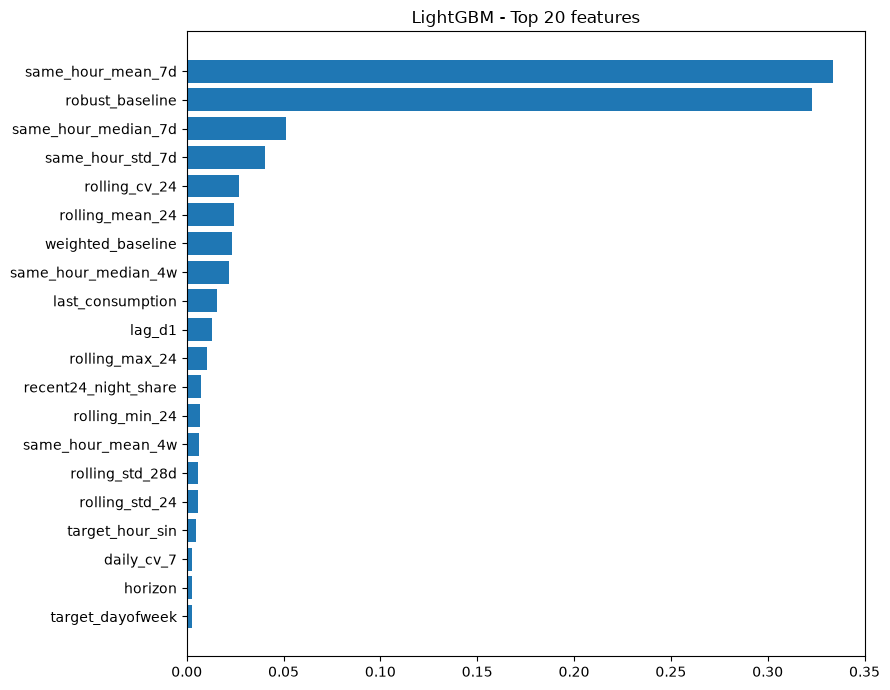

XGBoost 125 -> 49


,feature,importance,importance_norm,importance_cumulative
0,robust_baseline,0.374520,0.374520,0.374520
1,same_hour_mean_7d,0.087447,0.087447,0.461967
2,same_hour_median_7d,0.064239,0.064239,0.526206
3,rolling_mean_168,0.034319,0.034319,0.560526
4,daily_mean_7,0.028963,0.028963,0.589489
5,target_hour,0.019146,0.019146,0.608635
6,weighted_baseline,0.018756,0.018756,0.627391
7,same_hour_std_7d,0.018543,0.018543,0.645934
8,lag_d1,0.017852,0.017852,0.663787
9,rolling_std_168,0.015760,0.015760,0.679546


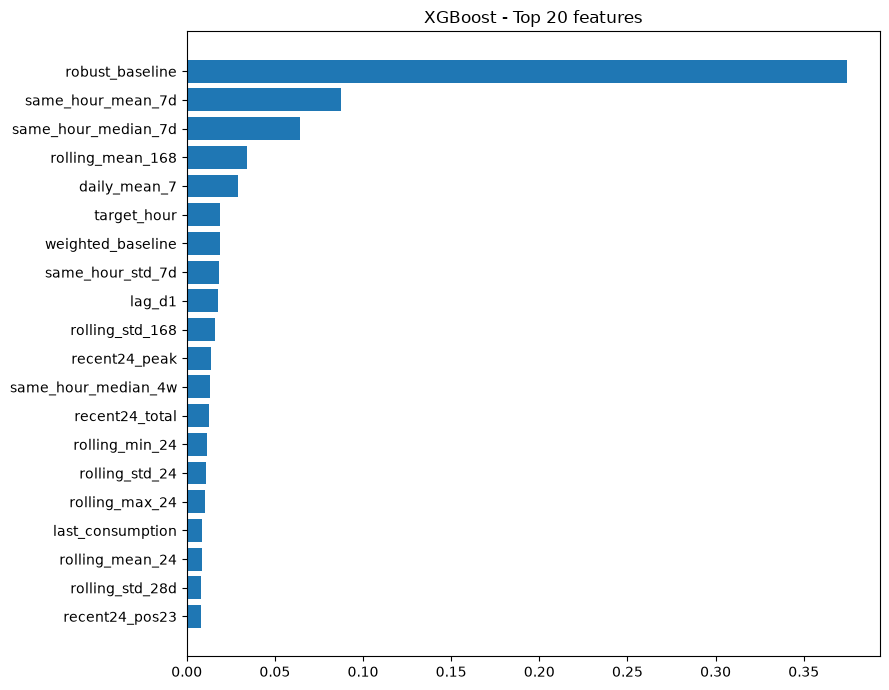

CatBoost 125 -> 46


,feature,importance,importance_norm,importance_cumulative
0,robust_baseline,45.095810,0.450958,0.450958
1,weighted_baseline,10.760112,0.107601,0.558559
2,same_hour_median_4w,5.875138,0.058751,0.617311
3,lag_d1,5.601081,0.056011,0.673321
4,same_hour_mean_4w,5.373776,0.053738,0.727059
5,same_hour_mean_7d,1.619863,0.016199,0.743258
6,lag_d2,1.563998,0.015640,0.758898
7,target_hour_sin,1.534005,0.015340,0.774238
8,same_hour_median_7d,1.349753,0.013498,0.787735
9,lag_d14,1.127540,0.011275,0.799011


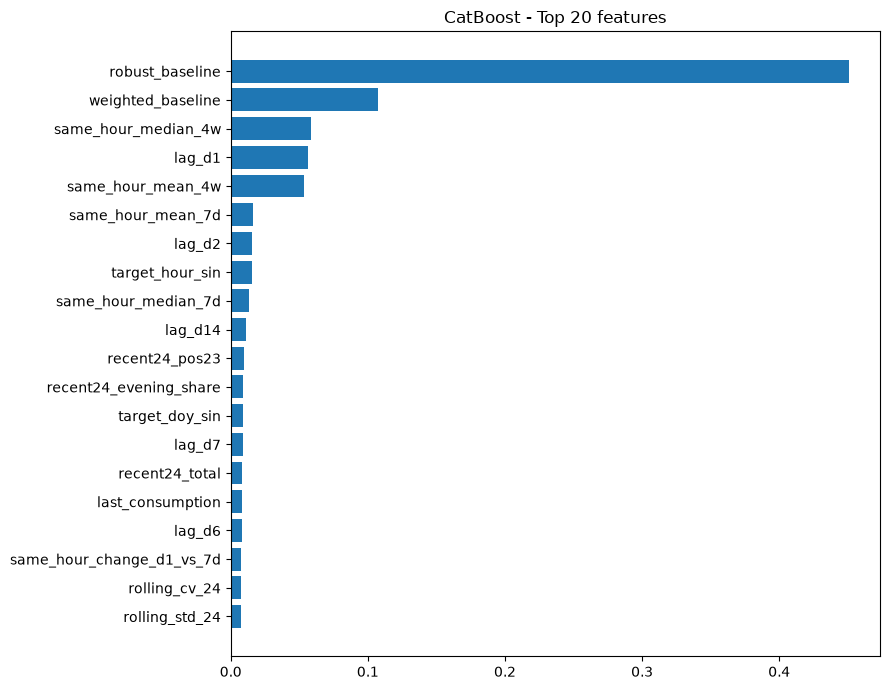

In [ ]:
PROTECTED_FEATURES=['horizon','target_hour_sin','target_hour_cos','target_dow_sin','target_dow_cos','robust_baseline',
                    'lag_d1','lag_d7','same_hour_mean_7d','same_hour_mean_4w','temperature_2m']

def importance_df(name, model, features):
    if name=='LightGBM':
        imp=model.booster_.feature_importance(importance_type='gain')
    elif name=='XGBoost':
        imp=model.feature_importances_
    else:
        imp=model.get_feature_importance()

    out=pd.DataFrame({'feature':features,'importance':np.asarray(imp,dtype=float)})
    total=out.importance.sum()
    out['importance_norm']=out.importance/total if total>0 else 1/len(out)
    out=out.sort_values('importance_norm',ascending=False).reset_index(drop=True)
    out['importance_cumulative']=out.importance_norm.cumsum()
    return out

def select_features(imp):
    reached=np.flatnonzero(
        imp.importance_cumulative.to_numpy()>=FEATURE_IMPORTANCE_CUMULATIVE_THRESHOLD
    )
    n_auto=(int(reached[0])+1) if len(reached) else len(imp)
    n=max(MIN_SELECTED_FEATURES,n_auto)
    n=min(MAX_SELECTED_FEATURES,n)

    selected=imp.feature.iloc[:n].tolist()

    for f in PROTECTED_FEATURES:
        if f in FEATURE_COLUMNS_BASE and f not in selected:
            selected.append(f)

    return selected

feature_importances={}
selected_features={}

for name,m in base_models.items():
    imp=importance_df(name,m,FEATURE_COLUMNS_BASE)
    feature_importances[name]=imp
    selected_features[name]=select_features(imp)

    imp.to_csv(ARTIFACTS_DIR/f'{name}_feature_importance.csv',index=False)
    joblib.dump(selected_features[name],ARTIFACTS_DIR/f'{name}_selected_features.pkl')

    print(name, len(FEATURE_COLUMNS_BASE),'->',len(selected_features[name]))
    display(imp.head(25))

    top=imp.head(20).sort_values('importance_norm')
    plt.figure(figsize=(9,7))
    plt.barh(top.feature,top.importance_norm)
    plt.title(f'{name} - Top 20 features')
    plt.tight_layout()
    plt.show()

Reentrenar modelos con features seleccionadas y comparar las 6 variantes:

,model,scope,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,LightGBM_base,overall,0,996840,0.085277,0.205956,48.268772,42.329279,0.404740
1,LightGBM_selected,overall,0,996840,0.085498,0.206758,48.394050,42.408366,0.400098
2,XGBoost_selected,overall,0,996840,0.085498,0.207468,48.394210,42.804221,0.395967
3,XGBoost_base,overall,0,996840,0.085674,0.206531,48.493328,43.766750,0.401412
4,CatBoost_base,overall,0,996840,0.085753,0.206721,48.538416,42.913204,0.400308
5,CatBoost_selected,overall,0,996840,0.085878,0.206816,48.609289,42.925108,0.399757
6,Robust_multiweek_median,overall,0,996840,0.089564,0.210407,50.695257,43.942643,0.378733
7,SameHour_median_7d,overall,0,996840,0.093907,0.218615,53.153929,45.243534,0.329317
8,SameHour_mean_7d,overall,0,996840,0.103752,0.210141,58.726210,50.884164,0.380304
9,Naive_mean_D1_W1,overall,0,996840,0.107239,0.225781,60.699768,49.613036,0.284631


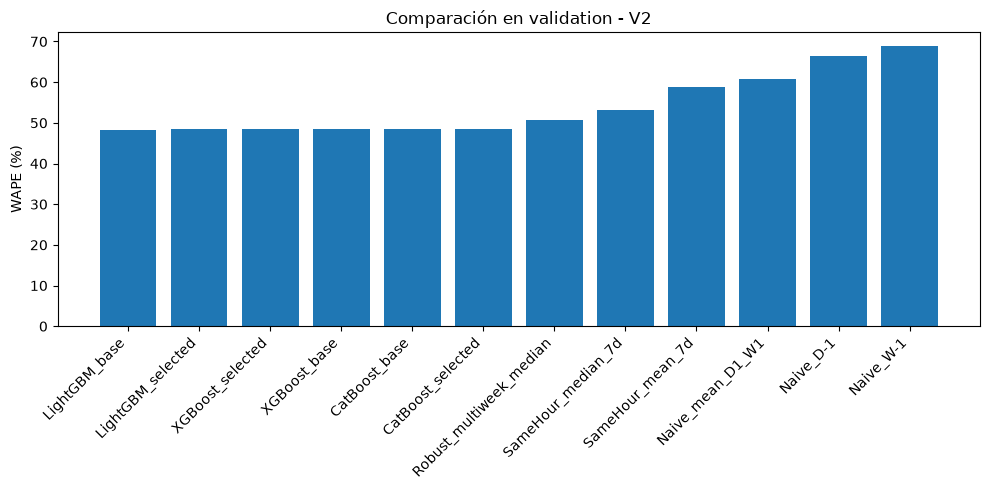

In [ ]:
selected_models={}
selected_results=[]

for name in MODEL_NAMES:
    feats=selected_features[name]

    Xtr2,ytr2=prepare_xy(base_train,feats)
    Xva2,yva2=prepare_xy(base_val,feats)

    m=build_model(name)
    m.fit(Xtr2,ytr2)
    selected_models[name]=m

    joblib.dump(m,ARTIFACTS_DIR/f'{name}_selected.pkl')

    pred=restore_prediction(base_val,m.predict(Xva2))
    selected_results.append(eval_predictions(base_val,pred,f'{name}_selected'))

selected_results=pd.concat(selected_results,ignore_index=True)

validation_all=pd.concat(
    [baseline_results,base_results,selected_results],
    ignore_index=True,
)

validation_overall=(
    validation_all[
        validation_all.scope=='overall'
    ]
    .sort_values(['WAPE_pct','MAE'])
    .reset_index(drop=True)
)

validation_overall.to_csv(
    ARTIFACTS_DIR/'validation_model_comparison.csv',
    index=False,
)

display(validation_overall)

plt.figure(figsize=(10,5))
p=validation_overall.sort_values('WAPE_pct')
plt.bar(p.model,p.WAPE_pct)
plt.xticks(rotation=45,ha='right')
plt.ylabel('WAPE (%)')
plt.title('Comparación en validation - V2')
plt.tight_layout()
plt.show()

Ganador pre-Optuna: LightGBM_base
Target: raw
Features: 125


,variant,WAPE_pct,n,MAE,RMSE,sMAPE_pct,R2
0,sin_user_id,48.268772,NaN,NaN,NaN,NaN,NaN
1,con_user_id,48.552629,996840.0,0.085778,0.205329,43.82796,0.408357


Usar user_id en el modelo principal: False


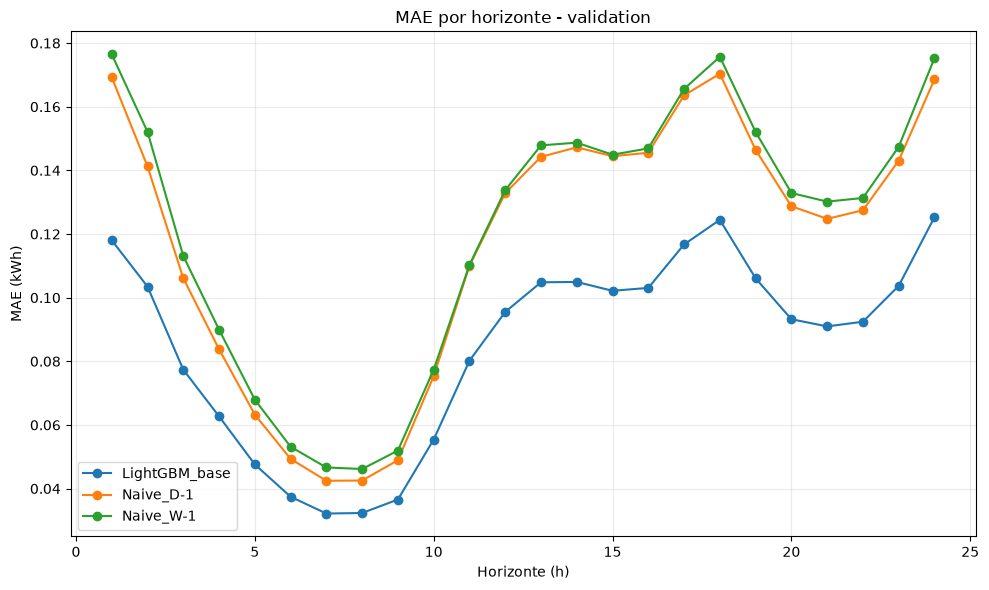

In [ ]:
ml_candidates=validation_overall[
    validation_overall.model.str.startswith(tuple(MODEL_NAMES))
].copy()

BEST_VARIANT_NAME=ml_candidates.iloc[0].model

if BEST_VARIANT_NAME.endswith('_base'):
    BEST_MODEL_NAME=BEST_VARIANT_NAME.replace('_base','')
    BEST_FEATURES=FEATURE_COLUMNS_BASE
else:
    BEST_MODEL_NAME=BEST_VARIANT_NAME.replace('_selected','')
    BEST_FEATURES=selected_features[BEST_MODEL_NAME]

print('Ganador pre-Optuna:',BEST_VARIANT_NAME)
print('Target:',BEST_TARGET_MODE)
print('Features:',len(BEST_FEATURES))

joblib.dump(
    BEST_FEATURES,
    ARTIFACTS_DIR/'best_preoptuna_features.pkl',
)

def training_target(df):
    if BEST_TARGET_MODE=='raw':
        return df['target'].astype('float32')
    if BEST_TARGET_MODE=='residual':
        return df['target_residual'].astype('float32')
    raise ValueError(BEST_TARGET_MODE)

def prepare_model_frame(
    df,
    features,
    model_name,
    use_user_id=False,
    user_categories=None,
):
    numeric_features=[f for f in features if f!='user_id']

    X=(
        df[numeric_features]
        .replace([np.inf,-np.inf],np.nan)
        .astype('float32')
    )

    fit_kwargs={}
    categories=user_categories

    if use_user_id:
        if model_name=='LightGBM':
            if categories is None:
                categories=sorted(df['user_id'].astype(str).unique())

            X.insert(
                0,
                'user_id',
                pd.Categorical(
                    df['user_id'].astype(str),
                    categories=categories,
                ),
            )
            fit_kwargs={'categorical_feature':['user_id']}

        elif model_name=='CatBoost':
            X.insert(
                0,
                'user_id',
                df['user_id'].astype(str).to_numpy(),
            )
            fit_kwargs={'cat_features':['user_id']}

        else:
            use_user_id=False

    return X, categories, fit_kwargs

def fit_candidate_model(
    train_df,
    model_name,
    features,
    params=None,
    use_user_id=False,
):
    model=build_model(model_name,params)

    X,categories,fit_kwargs=prepare_model_frame(
        train_df,
        features,
        model_name,
        use_user_id=use_user_id,
    )

    model.fit(
        X,
        training_target(train_df),
        **fit_kwargs,
    )

    return {
        'model':model,
        'model_name':model_name,
        'features':list(features),
        'use_user_id':bool(use_user_id and model_name in ['LightGBM','CatBoost']),
        'user_categories':categories
    }

def predict_candidate_model(model_info, df):
    X,_,_=prepare_model_frame(
        df,
        model_info['features'],
        model_info['model_name'],
        use_user_id=model_info['use_user_id'],
        user_categories=model_info.get('user_categories')
    )

    internal=model_info['model'].predict(X)
    return restore_prediction(df,internal)

BEST_USE_USER_ID=False

base_wape=float(
    validation_overall.loc[
        validation_overall['model']==BEST_VARIANT_NAME,
        'WAPE_pct',
    ].iloc[0]
)

personalization_rows=[
    {
        'variant':'sin_user_id',
        'WAPE_pct':base_wape,
    }
]

if (
    USE_USER_ID_PERSONALIZATION
    and BEST_MODEL_NAME in ['LightGBM','CatBoost']
):
    personalized_info=fit_candidate_model(
        base_train,
        BEST_MODEL_NAME,
        BEST_FEATURES,
        use_user_id=True,
    )

    personalized_pred=predict_candidate_model(
        personalized_info,
        base_val,
    )

    personalized_metrics=regression_metrics(
        base_val['target'],
        personalized_pred,
    )

    personalization_rows.append({
        'variant':'con_user_id',
        **personalized_metrics,
    })

    BEST_USE_USER_ID=(
        personalized_metrics['WAPE_pct'] < base_wape
    )

personalization_results=pd.DataFrame(personalization_rows)
display(personalization_results)

print('Usar user_id en el modelo principal:',BEST_USE_USER_ID)

plot_models=['Naive_D-1','Naive_W-1',BEST_VARIANT_NAME]
h=validation_all[
    (validation_all.scope=='horizon')
    & validation_all.model.isin(plot_models)
]

plt.figure(figsize=(10,6))
for name,part in h.groupby('model'):
    part=part.sort_values('horizon')
    plt.plot(part.horizon,part.MAE,marker='o',label=name)

plt.xlabel('Horizonte (h)')
plt.ylabel('MAE (kWh)')
plt.title('MAE por horizonte - validation')
plt.legend()
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

Optuna sobre el candidato ganador:

In [ ]:
def build_sample_dataset_horizons(
    split_day_limits,
    horizons,
    allowed_user_ids=None,
):
    pf=pq.ParquetFile(FILTERED_CONSUMPTION)
    chunks=[]

    for rg in tqdm(
        range(pf.num_row_groups),
        desc=f'Muestra horizons={horizons}',
    ):
        g=pf.read_row_group(rg).to_pandas()

        for uid,udf in g.groupby('user_id',sort=False):
            uid=str(uid)

            if (
                allowed_user_ids is not None
                and uid not in allowed_user_ids
            ):
                continue

            rows=build_forecast_rows_for_user(
                udf,
                split_day_limits,
                horizons=horizons,
            )

            if not rows.empty:
                chunks.append(rows)

    return pd.concat(chunks,ignore_index=True) if chunks else pd.DataFrame()


tune_sample=build_sample_dataset_horizons(
    {
        'train':TUNE_TRAIN_DAYS_PER_USER,
        'validation':TUNE_VAL_DAYS_PER_USER,
    },
    horizons=TUNE_HORIZONS,
)

tune_train=tune_sample[
    (tune_sample.split=='train')
    & (tune_sample.target_imputed==0)
].copy()

tune_val=tune_sample[
    (tune_sample.split=='validation')
    & (tune_sample.target_imputed==0)
    & tune_sample.user_id.isin(evaluation_users)
].copy()

X_tune_train,tune_categories,tune_fit_kwargs=prepare_model_frame(
    tune_train,
    BEST_FEATURES,
    BEST_MODEL_NAME,
    use_user_id=BEST_USE_USER_ID,
)

X_tune_val,_,_=prepare_model_frame(
    tune_val,
    BEST_FEATURES,
    BEST_MODEL_NAME,
    use_user_id=BEST_USE_USER_ID,
    user_categories=tune_categories,
)

y_tune_train=training_target(tune_train)

print(
    'Optuna train:',len(tune_train),
    '| validation:',len(tune_val),
    '| horizons:',TUNE_HORIZONS,
    '| user_id:',BEST_USE_USER_ID,
)

Muestra horizons=[1, 6, 12, 18, 24]: 100%|██████████| 1010/1010 [06:31<00:00,  2.58it/s]


Optuna train: 909000 | validation: 276900 | horizons: [1, 6, 12, 18, 24] | user_id: False


Best trial: 23. Best value: 48.6084: 100%|██████████| 30/30 [1:45:53<00:00, 211.79s/it]


Best WAPE: 48.60836272806937
{'n_estimators': 1316, 'learning_rate': 0.03298065081252858, 'num_leaves': 166, 'max_depth': 16, 'min_child_samples': 189, 'subsample': 0.8898808230673814, 'colsample_bytree': 0.6791960833775456, 'reg_alpha': 1.9953742738255272e-05, 'reg_lambda': 6.092392180585382e-06}


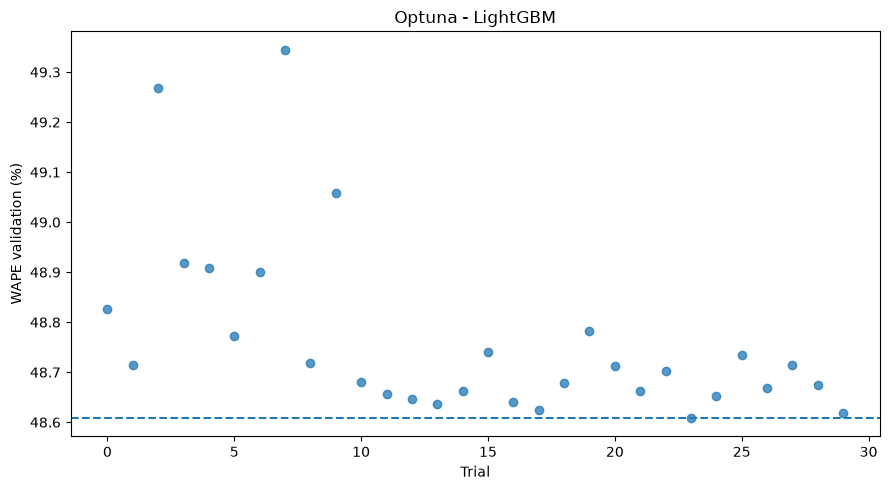

In [ ]:
def suggest_params(trial,name):
    if name=='LightGBM':
        return dict(
            n_estimators=trial.suggest_int('n_estimators',400,1400),
            learning_rate=trial.suggest_float('learning_rate',.015,.10,log=True),
            num_leaves=trial.suggest_int('num_leaves',31,180),
            max_depth=trial.suggest_int('max_depth',5,16),
            min_child_samples=trial.suggest_int('min_child_samples',30,220),
            subsample=trial.suggest_float('subsample',.75,1.),
            colsample_bytree=trial.suggest_float('colsample_bytree',.65,1.),
            reg_alpha=trial.suggest_float('reg_alpha',1e-6,5.,log=True),
            reg_lambda=trial.suggest_float('reg_lambda',1e-6,10.,log=True),
        )
    if name=='XGBoost':
        return dict(
            n_estimators=trial.suggest_int('n_estimators',400,1200),
            learning_rate=trial.suggest_float('learning_rate',.015,.10,log=True),
            max_depth=trial.suggest_int('max_depth',4,11),
            min_child_weight=trial.suggest_float('min_child_weight',1.,20.),
            subsample=trial.suggest_float('subsample',.75,1.),
            colsample_bytree=trial.suggest_float('colsample_bytree',.65,1.),
            gamma=trial.suggest_float('gamma',0.,5.),
            reg_alpha=trial.suggest_float('reg_alpha',1e-6,5.,log=True),
            reg_lambda=trial.suggest_float('reg_lambda',1e-6,10.,log=True),
        )
    if name=='CatBoost':
        return dict(
            iterations=trial.suggest_int('iterations',400,1200),
            learning_rate=trial.suggest_float('learning_rate',.015,.10,log=True),
            depth=trial.suggest_int('depth',6,10),
            l2_leaf_reg=trial.suggest_float('l2_leaf_reg',1e-3,20.,log=True),
            random_strength=trial.suggest_float('random_strength',0.,4.),
            bagging_temperature=trial.suggest_float('bagging_temperature',0.,4.),
        )
    raise ValueError(name)

def objective(trial):
    m=build_model(
        BEST_MODEL_NAME,
        suggest_params(trial,BEST_MODEL_NAME),
    )

    m.fit(
        X_tune_train,
        y_tune_train,
        **tune_fit_kwargs,
    )

    internal=m.predict(X_tune_val)
    pred=restore_prediction(tune_val,internal)

    return regression_metrics(
        tune_val.target,
        pred,
    )['WAPE_pct']

study=optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)

study.optimize(
    objective,
    n_trials=N_OPTUNA_TRIALS,
    show_progress_bar=True,
)

print('Best WAPE:',study.best_value)
print(study.best_params)

with open(
    ARTIFACTS_DIR/'optuna_best_params.json',
    'w',
    encoding='utf-8',
) as f:
    json.dump(study.best_params,f,indent=2)

trials=study.trials_dataframe()

plt.figure(figsize=(9,5))
plt.scatter(trials.number,trials.value,alpha=.75)
plt.axhline(study.best_value,ls='--')
plt.xlabel('Trial')
plt.ylabel('WAPE validation (%)')
plt.title(f'Optuna - {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()

Reentrenamiento final con train + validation completo:

In [ ]:
DIRECT_FEATURES=[
    f for f in BEST_FEATURES
    if f!='horizon'
]

def build_direct_trainval_for_horizon(horizon):
    pf=pq.ParquetFile(FILTERED_CONSUMPTION)
    chunks=[]

    for rg in tqdm(
        range(pf.num_row_groups),
        desc=f'Dataset final h={horizon:02d}',
    ):
        g=pf.read_row_group(rg).to_pandas()

        for uid,udf in g.groupby('user_id',sort=False):
            rows=build_forecast_rows_for_user(
                udf,
                {
                    'train':DIRECT_TRAIN_DAYS_PER_USER,
                    'validation':DIRECT_VAL_DAYS_PER_USER,
                },
                horizons=[horizon],
            )

            if rows.empty:
                continue

            rows=rows[
                rows.split.isin(['train','validation'])
                & (rows.target_imputed==0)
            ]

            if not rows.empty:
                chunks.append(rows)

    return pd.concat(chunks,ignore_index=True) if chunks else pd.DataFrame()


DIRECT_MODELS={}

for h in range(1,FORECAST_HORIZON+1):
    final_h=build_direct_trainval_for_horizon(h)

    if final_h.empty:
        raise RuntimeError(f'No hay datos finales para horizonte {h}')

    info=fit_candidate_model(
        final_h,
        BEST_MODEL_NAME,
        DIRECT_FEATURES,
        params=study.best_params,
        use_user_id=BEST_USE_USER_ID,
    )

    DIRECT_MODELS[h]=info

    joblib.dump(
        info,
        ARTIFACTS_DIR/f'final_24h_h{h:02d}.pkl',
    )

    print(
        f'h={h:02d}: {len(final_h):,} filas | '
        f'user_id={info["use_user_id"]}'
    )

joblib.dump(
    DIRECT_FEATURES,
    ARTIFACTS_DIR/'final_24h_features.pkl',
)

with open(
    ARTIFACTS_DIR/'final_24h_config.json',
    'w',
    encoding='utf-8',
) as f:
    json.dump(
        {
            'algorithm':BEST_MODEL_NAME,
            'source_variant':BEST_VARIANT_NAME,
            'target_mode':BEST_TARGET_MODE,
            'features':DIRECT_FEATURES,
            'use_user_id': bool(BEST_USE_USER_ID),
            'optuna_best_params':study.best_params,
            'forecast_horizon':FORECAST_HORIZON,
            'origin_local_hour':FORECAST_ORIGIN_LOCAL_HOUR,
            'architecture':'24 direct horizon-specific models',
            'train_end':str(TRAIN_END_DATE),
            'val_end':str(VAL_END_DATE),
            'test_end':str(TEST_END_DATE),
            'max_imputed_pct':MAX_IMPUTED_PCT,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print('24 modelos finales guardados.')

Dataset final h=01:   0%|          | 0/1010 [00:00<?, ?it/s]

Dataset final h=01: 100%|██████████| 1010/1010 [02:49<00:00,  5.96it/s]


h=01: 917,519 filas | user_id=False


Dataset final h=02: 100%|██████████| 1010/1010 [02:46<00:00,  6.06it/s]


h=02: 917,519 filas | user_id=False


...

h=22: 917,519 filas | user_id=False


Dataset final h=23: 100%|██████████| 1010/1010 [03:01<00:00,  5.58it/s]


h=23: 917,519 filas | user_id=False


Dataset final h=24: 100%|██████████| 1010/1010 [03:00<00:00,  5.59it/s]


h=24: 917,519 filas | user_id=False
24 modelos finales guardados.


Evaluación final sobre test:

In [ ]:
def add_parts(total,y,p):
    y=np.asarray(y,dtype=float); p=np.asarray(p,dtype=float)
    v=np.isfinite(y)&np.isfinite(p); y=y[v]; p=p[v]

    if len(y)==0:
        return total

    e=p-y
    part={
        'n':len(y),
        'sae':np.abs(e).sum(),
        'sse':(e**2).sum(),
        'sum_abs_y':np.abs(y).sum(),
        'smape_sum':(
            2*np.abs(e)
            /np.maximum(np.abs(y)+np.abs(p),1e-8)
        ).sum(),
        'sum_y':y.sum(),
        'sum_y2':(y**2).sum(),
    }

    if total is None:
        return part

    for k in total:
        total[k]+=part[k]

    return total

def finish(parts):
    sst=parts['sum_y2']-(parts['sum_y']**2)/parts['n']
    return {
        'n':int(parts['n']),
        'MAE':parts['sae']/parts['n'],
        'RMSE':np.sqrt(parts['sse']/parts['n']),
        'WAPE_pct':100*parts['sae']/max(parts['sum_abs_y'],1e-8),
        'sMAPE_pct':100*parts['smape_sum']/parts['n'],
        'R2':1-parts['sse']/sst if sst>0 else np.nan,
    }

def evaluate_direct_models_test(
    direct_models,
    allowed_users,
):
    pf=pq.ParquetFile(FILTERED_CONSUMPTION)

    total=None
    hp={h:None for h in range(1,FORECAST_HORIZON+1)}
    user_parts={}
    prediction_chunks=[]

    for rg in tqdm(
        range(pf.num_row_groups),
        desc='Evaluando test V2',
    ):
        g=pf.read_row_group(rg).to_pandas()

        for uid,udf in g.groupby('user_id',sort=False):
            uid=str(uid)

            if uid not in allowed_users:
                continue

            rows=build_forecast_rows_for_user(
                udf,
                {'test':None},
            )

            rows=rows[
                (rows.split=='test')
                & (rows.target_imputed==0)
            ].copy()

            if rows.empty:
                continue

            user_total=None
            user_pred_chunks=[]

            for h,part in rows.groupby('horizon',sort=True):
                h=int(h)
                pred=predict_candidate_model(
                    direct_models[h],
                    part,
                )

                y=part.target.to_numpy()

                total=add_parts(total,y,pred)
                hp[h]=add_parts(hp[h],y,pred)
                user_total=add_parts(user_total,y,pred)

                small=part[
                    [
                        'user_id',
                        'origin_time_utc',
                        'target_time_utc',
                        'forecast_date',
                        'horizon',
                        'target',
                        'lag_d1',
                        'lag_d7',
                        'same_hour_mean_7d',
                        'robust_baseline'
                    ]
                ].copy()

                small['prediction']=pred
                user_pred_chunks.append(small)

            if user_total is not None:
                user_parts[uid]=user_total

            if user_pred_chunks:
                prediction_chunks.append(
                    pd.concat(user_pred_chunks,ignore_index=True)
                )

    test_predictions=pd.concat(
        prediction_chunks,
        ignore_index=True,
    )

    test_overall={
        'split':'test',
        **finish(total),
    }

    test_by_horizon=pd.DataFrame([
        {
            'horizon':h,
            **finish(parts),
        }
        for h,parts in hp.items()
        if parts is not None
    ])

    test_by_user=pd.DataFrame([
        {
            'user_id':uid,
            'split':'test',
            **finish(parts),
        }
        for uid,parts in user_parts.items()
    ])

    return (
        test_overall,
        test_by_horizon,
        test_by_user,
        test_predictions,
    )


(
    test_overall,
    test_by_horizon,
    test_by_user,
    test_predictions,
)=evaluate_direct_models_test(
    DIRECT_MODELS,
    evaluation_users,
)

pd.DataFrame([test_overall]).to_csv(
    ARTIFACTS_DIR/'final_test_metrics.csv',
    index=False,
)

test_by_horizon.to_csv(
    ARTIFACTS_DIR/'final_test_metrics_by_horizon.csv',
    index=False,
)

test_by_user.to_csv(
    ARTIFACTS_DIR/'final_test_metrics_by_user.csv',
    index=False,
)

test_predictions.to_parquet(
    ARTIFACTS_DIR/'final_test_predictions.parquet',
    index=False,
)

display(pd.DataFrame([test_overall]))
display(test_by_horizon)

Evaluando test V2: 100%|██████████| 1010/1010 [34:39<00:00,  2.06s/it]


,split,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,test,4027323,0.106797,0.247396,50.540091,45.939031,0.455462


,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,1,167854,0.127606,0.260104,42.738450,41.943430,0.554660
1,2,167832,0.108471,0.239493,44.451843,42.822935,0.536004
2,3,167854,0.085569,0.209963,44.740447,41.294148,0.553457
3,4,166911,0.064295,0.179135,43.831194,37.937148,0.528193
4,5,167835,0.049275,0.153826,39.566180,34.240891,0.645428
5,6,167836,0.041630,0.143824,36.509503,31.842276,0.699751
6,7,167836,0.038715,0.141778,35.838153,30.878069,0.658477
7,8,167836,0.040791,0.148028,37.100077,31.301291,0.636533
8,9,167838,0.052214,0.165986,40.075591,34.594627,0.605310
9,10,167839,0.078473,0.198505,43.737675,40.062953,0.576908


Comparación final con baselines en test:

In [ ]:
baseline_test_rows=[]

baseline_predictions={
    'Naive_D-1':test_predictions['lag_d1'].to_numpy(),
    'Naive_W-1':test_predictions['lag_d7'].to_numpy(),
    'Naive_mean_D1_W1':(
        test_predictions['lag_d1'].to_numpy()
        +test_predictions['lag_d7'].to_numpy()
    )/2,
    'SameHour_mean_7d':test_predictions['same_hour_mean_7d'].to_numpy(),
    'Robust_multiweek_median':test_predictions['robust_baseline'].to_numpy(),
}

for name,pred in baseline_predictions.items():
    row={'model':name}
    row.update(
        regression_metrics(
            test_predictions['target'],
            pred,
        )
    )
    baseline_test_rows.append(row)

test_baselines=pd.DataFrame(baseline_test_rows)

final_test_comparison=pd.concat(
    [
        test_baselines,
        pd.DataFrame([
            {
                'model':f'{BEST_MODEL_NAME}_direct24_Optuna_final',
                **{
                    k:v
                    for k,v in test_overall.items()
                    if k!='split'
                },
            }
        ]),
    ],
    ignore_index=True,
)

final_test_comparison.to_csv(
    ARTIFACTS_DIR/'final_test_comparison.csv',
    index=False,
)

display(
    final_test_comparison.sort_values('WAPE_pct')
)

model_wape=float(
    final_test_comparison.loc[
        final_test_comparison.model==f'{BEST_MODEL_NAME}_direct24_Optuna_final',
        'WAPE_pct',
    ].iloc[0]
)

d1_wape=float(
    final_test_comparison.loc[
        final_test_comparison.model=='Naive_D-1',
        'WAPE_pct',
    ].iloc[0]
)

skill_vs_d1=1-model_wape/d1_wape
print(f'Skill vs D-1: {100*skill_vs_d1:.2f}% de reducción relativa del error')

,model,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
5,LightGBM_direct24_Optuna_final,4027323,0.106797,0.247396,50.540091,45.939031,0.455462
4,Robust_multiweek_median,4027323,0.114470,0.260936,54.171132,48.613024,0.394224
3,SameHour_mean_7d,4027323,0.132570,0.260986,62.736701,56.435597,0.393993
2,Naive_mean_D1_W1,4027323,0.138106,0.281054,65.356574,55.291603,0.297210
0,Naive_D-1,4027323,0.151616,0.325545,71.749884,56.948142,0.057096
1,Naive_W-1,4027323,0.156826,0.336504,74.215640,59.685367,-0.007453


Skill vs D-1: 29.56% de reducción relativa del error


Energía 24 h y demanda agregada:

Métricas sobre energía total de 24 h:


,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,166843,1.449237,2.436555,28.551307,32.735107,0.730442


Métricas sobre demanda agregada:


,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,4366,44.573059,50.774784,22.876078,25.362604,0.470082


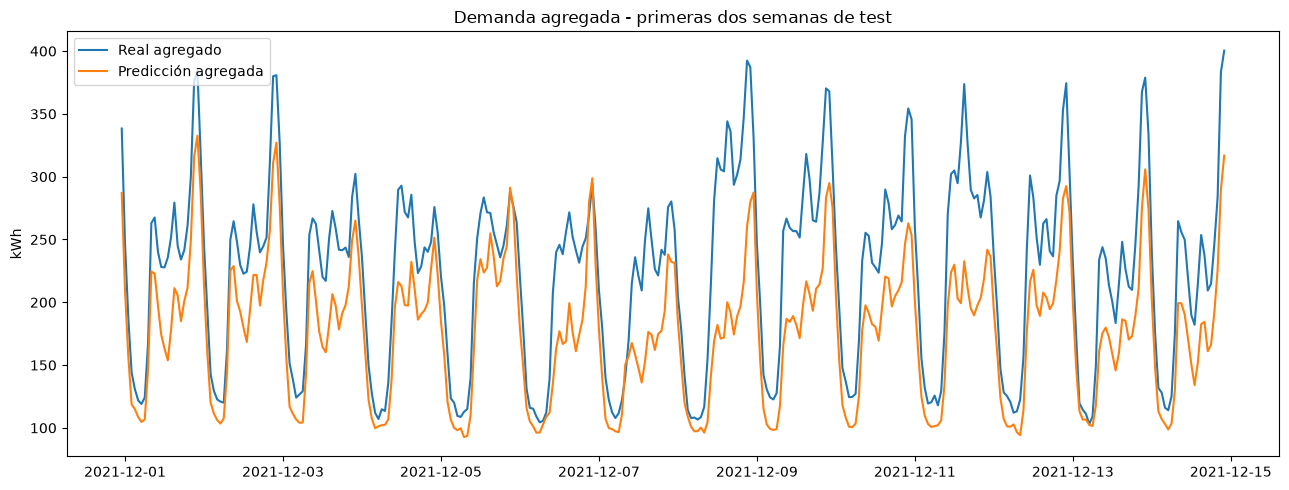

In [ ]:
daily_forecasts=(
    test_predictions
    .groupby(
        ['user_id','origin_time_utc'],
        as_index=False,
    )
    .agg(
        actual_24h=('target','sum'),
        predicted_24h=('prediction','sum'),
        n_hours=('horizon','count'),
    )
)

daily_forecasts=daily_forecasts[
    daily_forecasts['n_hours']==FORECAST_HORIZON
].copy()

daily_energy_metrics=regression_metrics(
    daily_forecasts['actual_24h'],
    daily_forecasts['predicted_24h'],
)

print('Métricas sobre energía total de 24 h:')
display(pd.DataFrame([daily_energy_metrics]))

aggregate_source=(
    test_predictions
    .sort_values(['user_id','target_time_utc','origin_time_utc'])
    .drop_duplicates(
        ['user_id','target_time_utc'],
        keep='last',
    )
)

aggregate=(
    aggregate_source
    .groupby(
        'target_time_utc',
        as_index=False,
    )
    .agg(
        actual=('target','sum'),
        prediction=('prediction','sum'),
        n_users=('user_id','nunique'),
    )
)

aggregate_metrics=regression_metrics(
    aggregate['actual'],
    aggregate['prediction'],
)

print('Métricas sobre demanda agregada:')
display(pd.DataFrame([aggregate_metrics]))

pd.DataFrame([daily_energy_metrics]).to_csv(
    ARTIFACTS_DIR/'final_test_daily_energy_metrics.csv',
    index=False,
)

pd.DataFrame([aggregate_metrics]).to_csv(
    ARTIFACTS_DIR/'final_test_aggregate_metrics.csv',
    index=False,
)

aggregate.to_parquet(
    ARTIFACTS_DIR/'final_test_aggregate_predictions.parquet',
    index=False,
)

plt.figure(figsize=(13,5))
plot_agg=aggregate.iloc[:24*14]
plt.plot(
    plot_agg['target_time_utc'],
    plot_agg['actual'],
    label='Real agregado',
)
plt.plot(
    plot_agg['target_time_utc'],
    plot_agg['prediction'],
    label='Predicción agregada',
)
plt.ylabel('kWh')
plt.title('Demanda agregada - primeras dos semanas de test')
plt.legend()
plt.tight_layout()
plt.show()

Gráficos de las métricas finales:

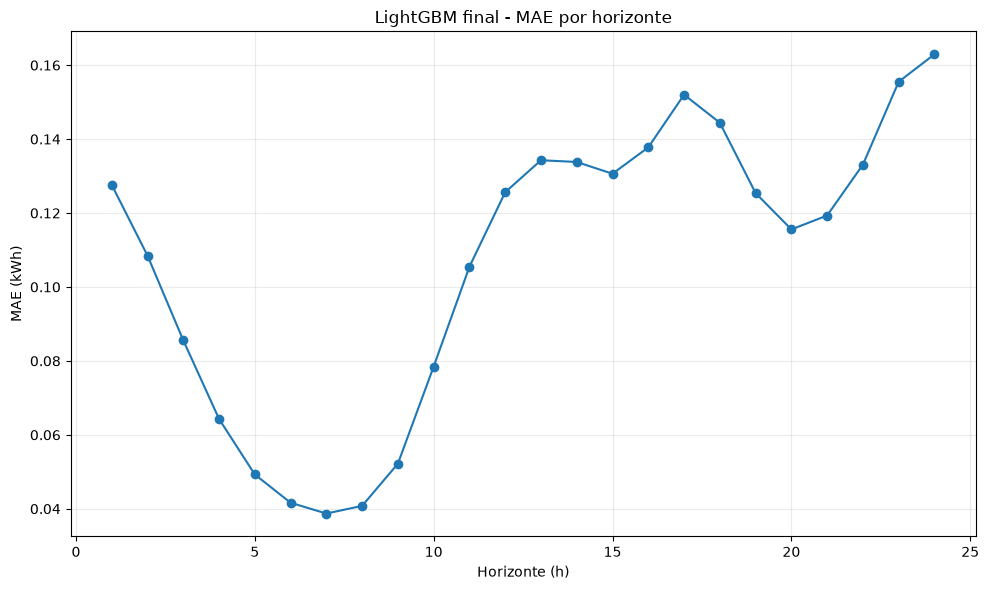

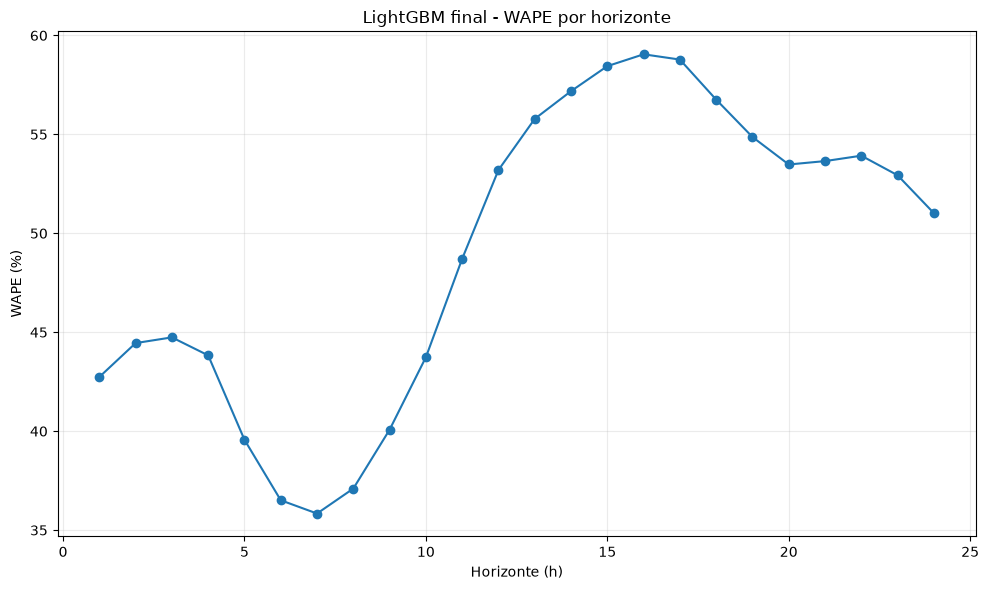

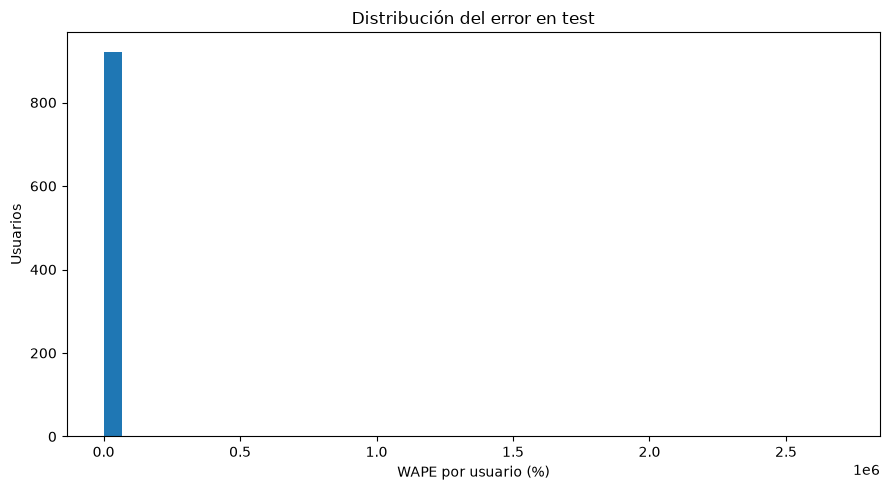

count    9.230000e+02
mean     2.986011e+03
std      8.916766e+04
min      1.937967e+00
10%      3.674104e+01
25%      4.346953e+01
50%      5.080907e+01
75%      5.807050e+01
90%      6.572896e+01
95%      7.168929e+01
max      2.709046e+06
Name: WAPE_pct, dtype: float64

In [46]:

plt.figure(figsize=(10,6)); plt.plot(test_by_horizon.horizon,test_by_horizon.MAE,marker='o'); plt.xlabel('Horizonte (h)'); plt.ylabel('MAE (kWh)'); plt.title(f'{BEST_MODEL_NAME} final - MAE por horizonte'); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,6)); plt.plot(test_by_horizon.horizon,test_by_horizon.WAPE_pct,marker='o'); plt.xlabel('Horizonte (h)'); plt.ylabel('WAPE (%)'); plt.title(f'{BEST_MODEL_NAME} final - WAPE por horizonte'); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
plt.figure(figsize=(9,5)); plt.hist(test_by_user.WAPE_pct.dropna(),bins=40); plt.xlabel('WAPE por usuario (%)'); plt.ylabel('Usuarios'); plt.title('Distribución del error en test'); plt.tight_layout(); plt.show()
display(test_by_user.WAPE_pct.describe(percentiles=[.1,.25,.5,.75,.9,.95]))


Gráficos del consumo real vs estimado para usuarios representativos:

['03cd65998fe0a9b9d368e73d96b2367758be5fd52b75d62b6502324dc3191cae', 'b3f99d61b2e879cd214bda6f896b4c1872163e4d0329d319041c959ca2720b14', '355caa6ce57e67c4e72060e603153ac172f29c7c9a398f671f39de0b0f082f49']


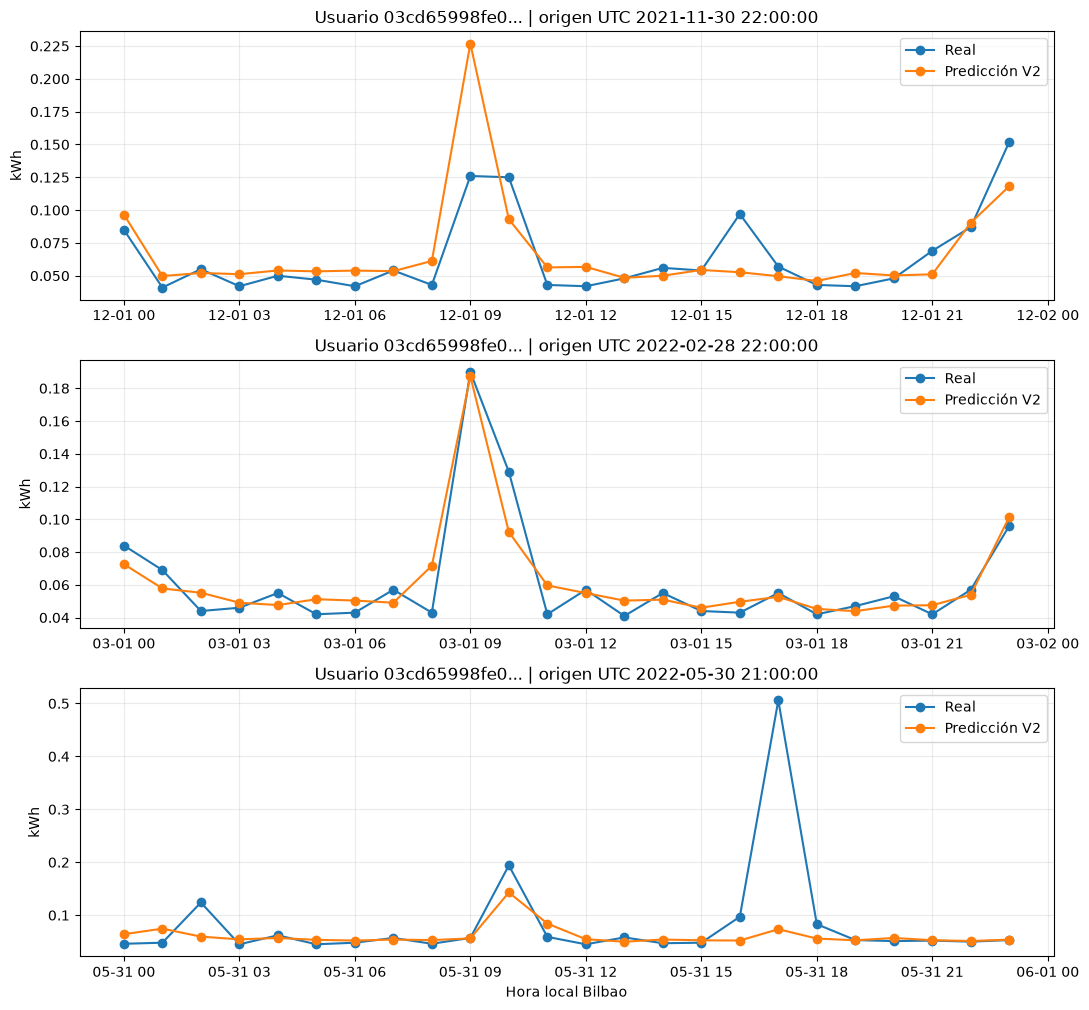

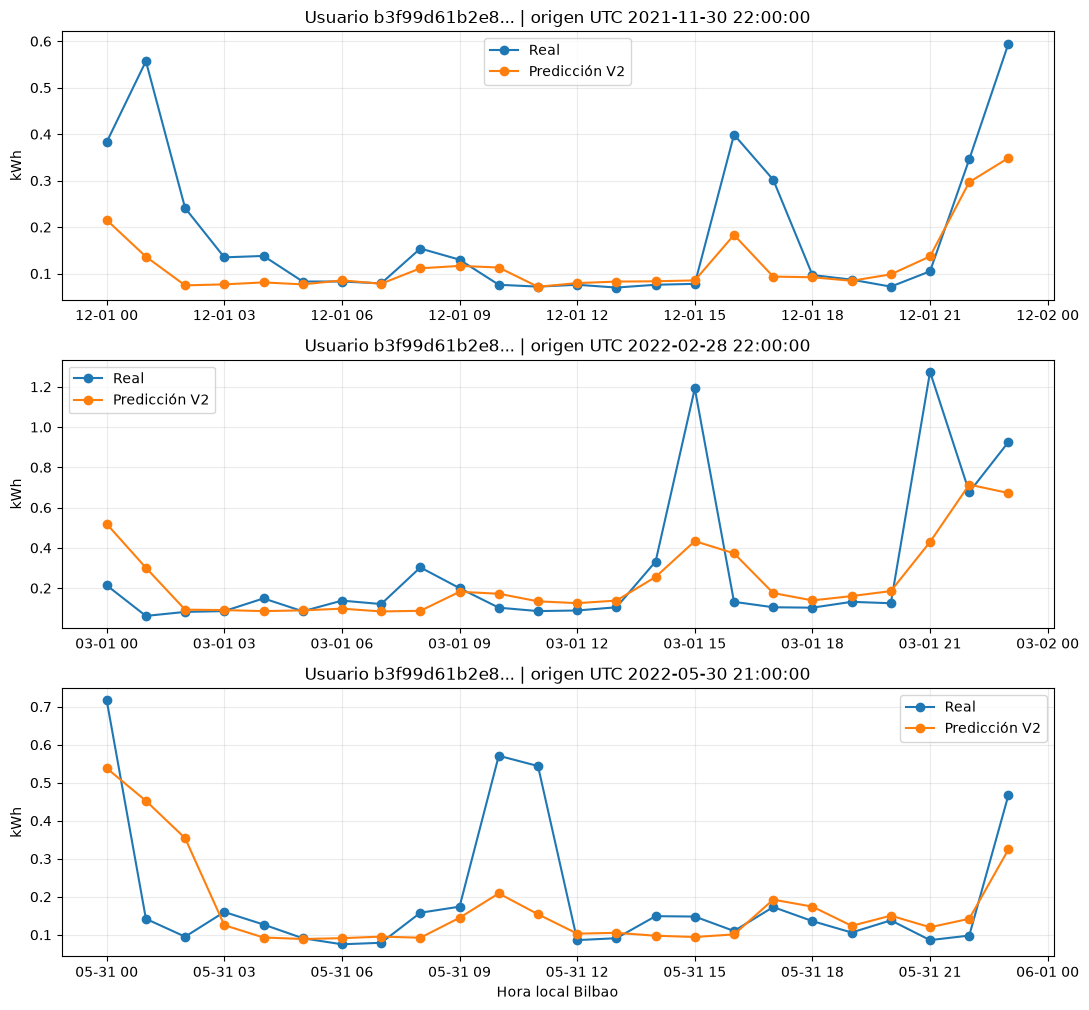

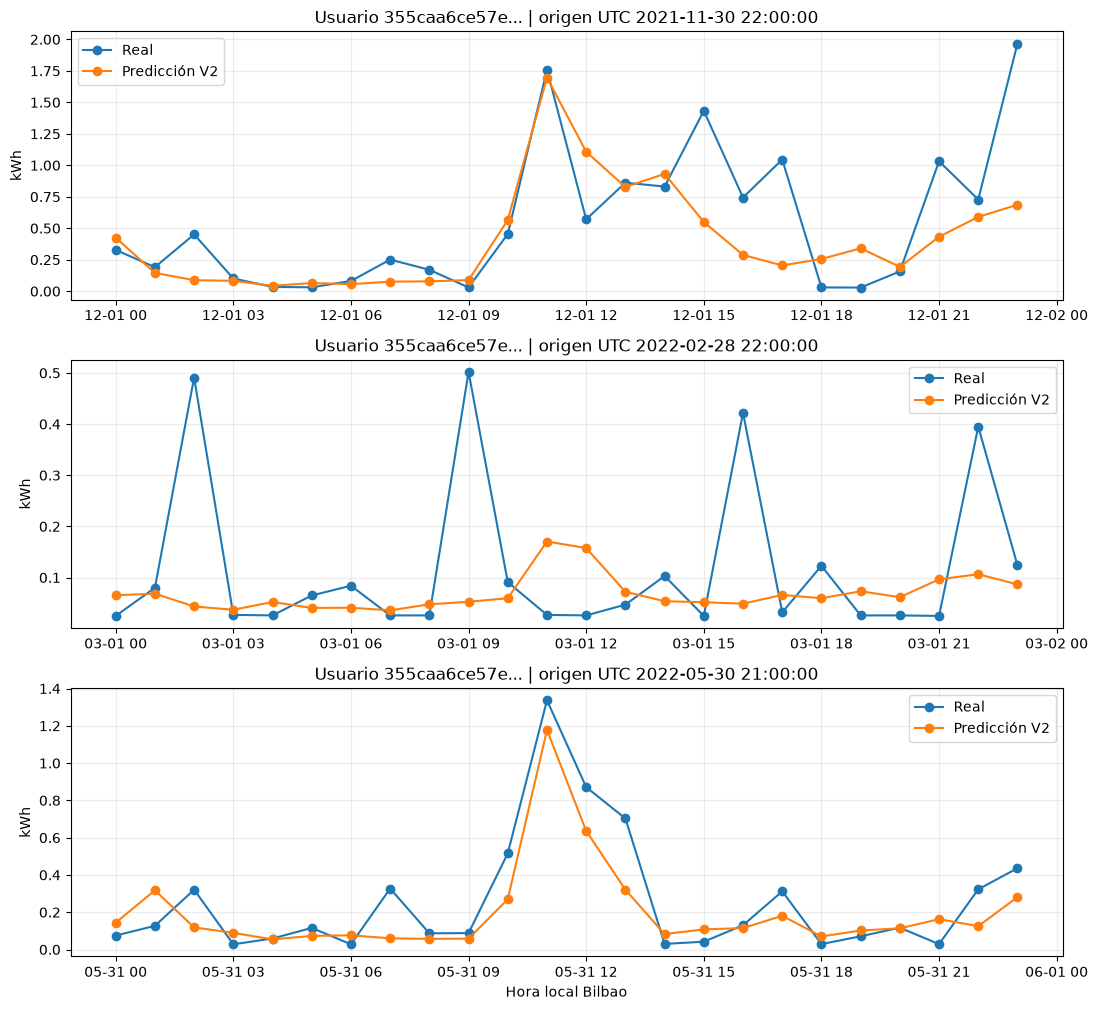

In [ ]:
su=test_by_user.sort_values('WAPE_pct').reset_index(drop=True)

plot_users=[
    su.iloc[max(0,int(.1*len(su))-1)].user_id,
    su.iloc[int(.5*len(su))].user_id,
    su.iloc[min(len(su)-1,int(.9*len(su)))].user_id,
]

print(plot_users)

for uid in plot_users:
    r=test_predictions[
        test_predictions.user_id.astype(str)==str(uid)
    ].copy()

    counts=r.groupby('origin_time_utc').size()
    origins=counts[counts==FORECAST_HORIZON].index

    if len(origins)==0:
        continue

    pos=np.linspace(
        0,
        len(origins)-1,
        num=min(3,len(origins)),
        dtype=int,
    )

    chosen=origins[pos]
    r=r[r.origin_time_utc.isin(chosen)].copy()

    r['target_time_local']=(
        to_local_time(r.target_time_utc)
        .tz_localize(None)
    )

    origins=r.origin_time_utc.drop_duplicates().tolist()

    fig,axes=plt.subplots(
        len(origins),
        1,
        figsize=(11,3.4*len(origins)),
        squeeze=False,
    )

    for ax,o in zip(axes.ravel(),origins):
        p=r[
            r.origin_time_utc==o
        ].sort_values('horizon')

        ax.plot(
            p.target_time_local,
            p.target,
            marker='o',
            label='Real',
        )

        ax.plot(
            p.target_time_local,
            p.prediction,
            marker='o',
            label='Predicción V2',
        )

        ax.set_title(
            f'Usuario {str(uid)[:12]}... | origen UTC {o}'
        )
        ax.set_ylabel('kWh')
        ax.grid(alpha=.25)
        ax.legend()

    axes.ravel()[-1].set_xlabel('Hora local Bilbao')
    fig.tight_layout()
    plt.show()